# Heart Disease Prediction - Analisis dan Modeling

Notebook ini berisi analisis lengkap untuk prediksi penyakit jantung menggunakan dataset Heart Disease dari UCI Machine Learning Repository dengan pendekatan:
1. Imputasi nilai outlier dengan **Median Imputation**
2. Feature selection menggunakan PCC dan Chi-Square
3. Model **ETCXGBHybrid** (ExtraTreesClassifier + XGBoost)


# 1. Pengumpulan dan Validasi Awal Data

## 1.1 Import Library

In [39]:
# Import library yang diperlukan
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import time

# Untuk machine learning
from sklearn.model_selection import train_test_split, StratifiedKFold
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import ExtraTreesClassifier
from sklearn.ensemble import RandomForestRegressor
from sklearn.feature_selection import SelectKBest, chi2
from sklearn.metrics import (
    accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report
)

# Untuk statistik
from scipy.stats import chi2_contingency

# Suppress warnings
warnings.filterwarnings('ignore')

# Konfigurasi visualisasi
plt.style.use('seaborn-v0_8-darkgrid')
sns.set_palette("husl")

# Konfigurasi pandas display
pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
pd.set_option('display.width', None)
pd.set_option('display.max_colwidth', None)

# Random state untuk reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)

print("✅ Library berhasil diimport")
print("=" * 80)
print("📚 Library yang digunakan:")
print("  • pandas untuk manipulasi data")
print("  • numpy untuk operasi numerik")
print("  • matplotlib & seaborn untuk visualisasi")
print("  • sklearn untuk machine learning dan preprocessing")
print("  • scipy untuk analisis statistik")
print("=" * 80)


✅ Library berhasil diimport
📚 Library yang digunakan:
  • pandas untuk manipulasi data
  • numpy untuk operasi numerik
  • matplotlib & seaborn untuk visualisasi
  • sklearn untuk machine learning dan preprocessing
  • scipy untuk analisis statistik


## 1.2 Load Dataset

In [40]:
# Mount Google Drive (untuk Google Colab)
try:
    from google.colab import drive
    drive.mount('/content/drive')
    PATH_DATASET = "/content/drive/MyDrive/Colab Notebooks/Heart_Disease-Paper-main/dataset.csv"
    print("Google Drive berhasil terhubung!")
except ImportError:
    # Jika tidak di Colab, gunakan path lokal
    PATH_DATASET = "dataset.csv"
    print("Berjalan di environment lokal")
    print("Pastikan file 'dataset.csv' ada di direktori yang sama")

print(f"📂 Path dataset: {PATH_DATASET}")


Berjalan di environment lokal
Pastikan file 'dataset.csv' ada di direktori yang sama
📂 Path dataset: dataset.csv


In [41]:
# Load dataset
df_original = pd.read_csv(PATH_DATASET)

# Tampilkan informasi dasar dataset
jumlah_baris, jumlah_kolom = df_original.shape
distribusi_target = df_original['target'].value_counts().to_dict()

print("INFORMASI DATASET")
print(f"\nDataset berhasil dimuat!")
print(f"Dimensi: {jumlah_baris} baris x {jumlah_kolom} kolom")
print(f"\n📋 Daftar kolom:")
for idx, nama_kolom in enumerate(df_original.columns, 1):
    print(f"  {idx}. {nama_kolom}")

print(f"\nVariabel target: 'target'")
print(f"   - Jumlah kelas: {df_original['target'].nunique()}")
print(f"   - Distribusi: {distribusi_target}")
print("=" * 60)


INFORMASI DATASET

Dataset berhasil dimuat!
Dimensi: 1025 baris x 14 kolom

📋 Daftar kolom:
  1. age
  2. sex
  3. cp
  4. trestbps
  5. chol
  6. fbs
  7. restecg
  8. thalach
  9. exang
  10. oldpeak
  11. slope
  12. ca
  13. thal
  14. target

Variabel target: 'target'
   - Jumlah kelas: 2
   - Distribusi: {1: 526, 0: 499}


# 2. Exploratory Data Analysis (EDA)

Tahap EDA bertujuan untuk memahami karakteristik data tanpa melakukan modifikasi. Analisis meliputi:
- Karakteristik umum dataset
- Distribusi target class
- Distribusi setiap fitur
- Identifikasi nilai ekstrem

## 2.1 Karakteristik Umum Dataset

Pada tahap ini dilakukan pemeriksaan karakteristik dasar dataset untuk memahami struktur dan kualitas data.

In [42]:
"""
Menampilkan karakteristik umum dataset setelah validasi awal
"""

print("KARAKTERISTIK DATASET UCI HEART DISEASE")

# 1. Dimensi dataset
print("\n1. DIMENSI DATASET:")
print(f"   • Jumlah sampel: {df_original.shape[0]}")
print(f"   • Jumlah kolom: {df_original.shape[1] - 1}  + 1 target/label")

# 2. Informasi tipe data
print("\n2. INFORMASI KOLOM:")
print(df_original.info())

# 3. Statistik deskriptif
print("\n3. STATISTIK DESKRIPTIF:")
display(df_original.describe())

# 4. Missing values
print("\n4. MISSING VALUES:")
missing = df_original.isnull().sum()
missing_pct = (missing / len(df_original)) * 100
df_missing = pd.DataFrame({
    'Jumlah': missing[missing > 0],
    'Persentase (%)': missing_pct[missing > 0].round(2)
})
if len(df_missing) > 0:
    display(df_missing)
else:
    print("  Tidak ada missing values")


KARAKTERISTIK DATASET UCI HEART DISEASE

1. DIMENSI DATASET:
   • Jumlah sampel: 1025
   • Jumlah kolom: 13  + 1 target/label

2. INFORMASI KOLOM:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1025 entries, 0 to 1024
Data columns (total 14 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   age       1025 non-null   int64  
 1   sex       1025 non-null   int64  
 2   cp        1025 non-null   int64  
 3   trestbps  1025 non-null   int64  
 4   chol      1025 non-null   int64  
 5   fbs       1025 non-null   int64  
 6   restecg   1025 non-null   int64  
 7   thalach   1025 non-null   int64  
 8   exang     1025 non-null   int64  
 9   oldpeak   1025 non-null   float64
 10  slope     1025 non-null   int64  
 11  ca        1025 non-null   int64  
 12  thal      1025 non-null   int64  
 13  target    1025 non-null   int64  
dtypes: float64(1), int64(13)
memory usage: 112.2 KB
None

3. STATISTIK DESKRIPTIF:


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
count,1025.000000,1025.000000,1025.000000,1025.000000,1025.00000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000,1025.000000
mean,54.434146,0.695610,0.942439,131.611707,246.00000,0.149268,0.529756,149.114146,0.336585,1.071512,1.385366,0.754146,2.323902,0.513171
std,9.072290,0.460373,1.029641,17.516718,51.59251,0.356527,0.527878,23.005724,0.472772,1.175053,0.617755,1.030798,0.620660,0.500070
min,29.000000,0.000000,0.000000,94.000000,126.00000,0.000000,0.000000,71.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,48.000000,0.000000,0.000000,120.000000,211.00000,0.000000,0.000000,132.000000,0.000000,0.000000,1.000000,0.000000,2.000000,0.000000
50%,56.000000,1.000000,1.000000,130.000000,240.00000,0.000000,1.000000,152.000000,0.000000,0.800000,1.000000,0.000000,2.000000,1.000000
75%,61.000000,1.000000,2.000000,140.000000,275.00000,0.000000,1.000000,166.000000,1.000000,1.800000,2.000000,1.000000,3.000000,1.000000
max,77.000000,1.000000,3.000000,200.000000,564.00000,1.000000,2.000000,202.000000,1.000000,6.200000,2.000000,4.000000,3.000000,1.000000



4. MISSING VALUES:
  Tidak ada missing values


## 2.2 Distribusi Target Class

Distribusi kelas target menunjukkan proporsi pasien yang terdiagnosis penyakit jantung dibandingkan yang tidak. Keseimbangan distribusi class berimplikasi pada strategi modeling yang digunakan.

DISTRIBUSI TARGET CLASS

Distribusi Target:
  • Tidak Sakit (0): 499 sampel (48.68%)
  • Sakit (1): 526 sampel (51.32%)


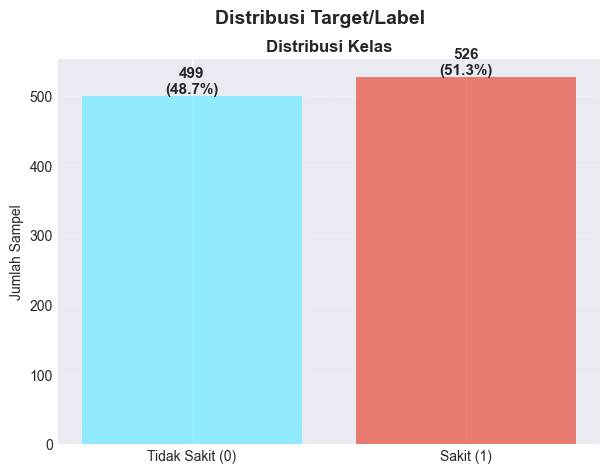

In [43]:
"""
Visualisasi distribusi target class untuk memahami keseimbangan dataset
"""

print("DISTRIBUSI TARGET CLASS")

#Visualisasi barplot saja
fig, axes = plt.subplots(1, 1, figsize=(7, 5))
fig.suptitle('Distribusi Target/Label', fontsize=14, fontweight='bold')

# Count plot
target_counts = df_original['target'].value_counts().sort_index()
ax1 = axes
bars = ax1.bar(['Tidak Sakit (0)', 'Sakit (1)'], target_counts.values, 
                color=["#6aebff", '#e74c3c'], alpha=0.7, linewidth=2)

# Label pada bar
for bar, count in zip(bars, target_counts.values):
    height = bar.get_height()
    percentage = (count / target_counts.sum()) * 100
    ax1.text(bar.get_x() + bar.get_width()/2., height,
            f'{count}\n({percentage:.1f}%)',
            ha='center', va='bottom', fontsize=11, fontweight='bold')

ax1.set_title('Distribusi Kelas', fontsize=12, fontweight='bold')
ax1.set_ylabel('Jumlah Sampel', fontsize=10)
ax1.grid(True, alpha=0.3, axis='y', linestyle='--')


# Statistik target
print(f"\nDistribusi Target:")
print(f"  • Tidak Sakit (0): {target_counts[0]} sampel ({target_counts[0]/len(df_original)*100:.2f}%)")
print(f"  • Sakit (1): {target_counts[1]} sampel ({target_counts[1]/len(df_original)*100:.2f}%)")


## 2.3 Analisis Distribusi Fitur

### Fitur Kontinyu

**a. Age (Usia)**

Fitur age merepresentasikan usia pasien dalam tahun. Dari distribusi terlihat bahwa:
- Rentang usia: 29-77 tahun
- Mayoritas pasien berusia 50-60 tahun (middle-aged)
- Distribusi cenderung normal dengan sedikit skewness ke kanan
- Terdapat beberapa nilai ekstrem pada usia sangat muda (<35) dan sangat tua (>70)

Secara klinis, risiko penyakit jantung meningkat seiring bertambahnya usia, sehingga fitur ini memiliki relevansi medis yang tinggi.

**b. Trestbps (Resting Blood Pressure)**

Fitur trestbps merepresentasikan tekanan darah saat istirahat (mmHg). Analisis menunjukkan:
- Rentang: 94-200 mmHg
- Rata-rata: ~131 mmHg (sedikit di atas normal 120 mmHg)
- Terdapat 9 missing values (dari validasi awal)
- Distribusi relatif normal dengan beberapa nilai ekstrem di ujung atas

Nilai tekanan darah tinggi (>140 mmHg) merupakan indikator hipertensi yang menjadi faktor risiko utama penyakit jantung.

**c. Chol (Serum Cholesterol)**

Fitur chol merepresentasikan kolesterol serum dalam mg/dl. Karakteristik:
- Rentang: 126-564 mg/dl
- Rata-rata: ~246 mg/dl (di atas batas normal 200 mg/dl)
- Terdapat 5 missing values
- Distribusi right-skewed dengan beberapa nilai sangat tinggi

Kolesterol tinggi (>200 mg/dl) meningkatkan risiko penyumbatan pembuluh darah dan penyakit jantung koroner.

**d. Thalach (Maximum Heart Rate Achieved)**

Fitur thalach merepresentasikan detak jantung maksimum yang dicapai saat tes stress. Pola distribusi:
- Rentang: 71-202 bpm
- Rata-rata: ~150 bpm
- Distribusi mendekati normal dengan sedikit left-skew
- Terdapat 1 missing value

Secara klinis, detak jantung maksimum yang rendah pada tes stress dapat mengindikasikan kapasitas jantung yang menurun.

**e. Oldpeak (ST Depression)**

Fitur oldpeak merepresentasikan depresi segmen ST yang diinduksi oleh exercise. Karakteristik:
- Rentang: -2.6 hingga 6.2
- Mayoritas nilai mendekati 0-2
- Distribusi sangat right-skewed
- Terdapat 5 missing values

ST depression yang signifikan (>2) merupakan indikator kuat iskemia jantung.

### Fitur kategorikal

**f. Sex (Jenis Kelamin)**

Encoding: 0=Female, 1=Male
- Distribusi: ~68% Male, ~32% Female
- Dataset memiliki bias gender karena penyakit jantung lebih prevalens pada pria
- Jenis kelamin adalah faktor risiko yang sudah diketahui secara medis

**g. CP (Chest Pain Type)**

Encoding: 0=typical angina, 1=atypical angina, 2=non-anginal pain, 3=asymptomatic
- Distribusi relatif merata dengan tipe 0 (typical angina) paling banyak
- Tipe chest pain adalah indikator penting untuk diagnosis awal
- Asymptomatic (tipe 3) menunjukkan kasus yang lebih sulit dideteksi

**h. FBS (Fasting Blood Sugar)**

Encoding: 0=<120 mg/dl, 1=>120 mg/dl
- Mayoritas pasien (~85%) memiliki FBS <120 mg/dl
- FBS >120 mg/dl mengindikasikan diabetes atau prediabetes
- Diabetes merupakan komorbiditas umum pada penyakit jantung

**i. RestECG (Resting Electrocardiographic)**

Encoding: 0=normal, 1=ST-T abnormality, 2=left ventricular hypertrophy
- Mayoritas pasien memiliki hasil ECG normal
- Abnormalitas ECG dapat mengindikasikan kerusakan jantung

**j. Exang (Exercise Induced Angina)**

Encoding: 0=No, 1=Yes
- Distribusi: ~67% No, ~33% Yes
- Angina yang dipicu oleh exercise adalah tanda kuat iskemia jantung

**k. Slope (Slope of Peak Exercise ST Segment)**

Encoding: 0=upsloping, 1=flat, 2=downsloping
- Mayoritas pasien memiliki slope tipe 1 (flat)
- Slope downsloping mengindikasikan iskemia yang lebih parah

**l. CA (Number of Major Vessels Colored by Fluoroscopy)**

Nilai valid: 0-3
- Mayoritas pasien memiliki ca=0 (tidak ada pembuluh tersumbat)
- Semakin tinggi ca, semakin banyak pembuluh yang tersumbat
- Terdapat 4 missing values (dari konversi ca=4)

**m. Thal (Thalassemia)**

Nilai valid: 1=normal, 2=fixed defect, 3=reversible defect
- Distribusi mayoritas pada tipe 2 (fixed defect)
- Thalassemia dapat menyebabkan anemia yang memperburuk kondisi jantung
- Terdapat 2 missing values (dari konversi thal=0)

VISUALISASI DISTRIBUSI FITUR


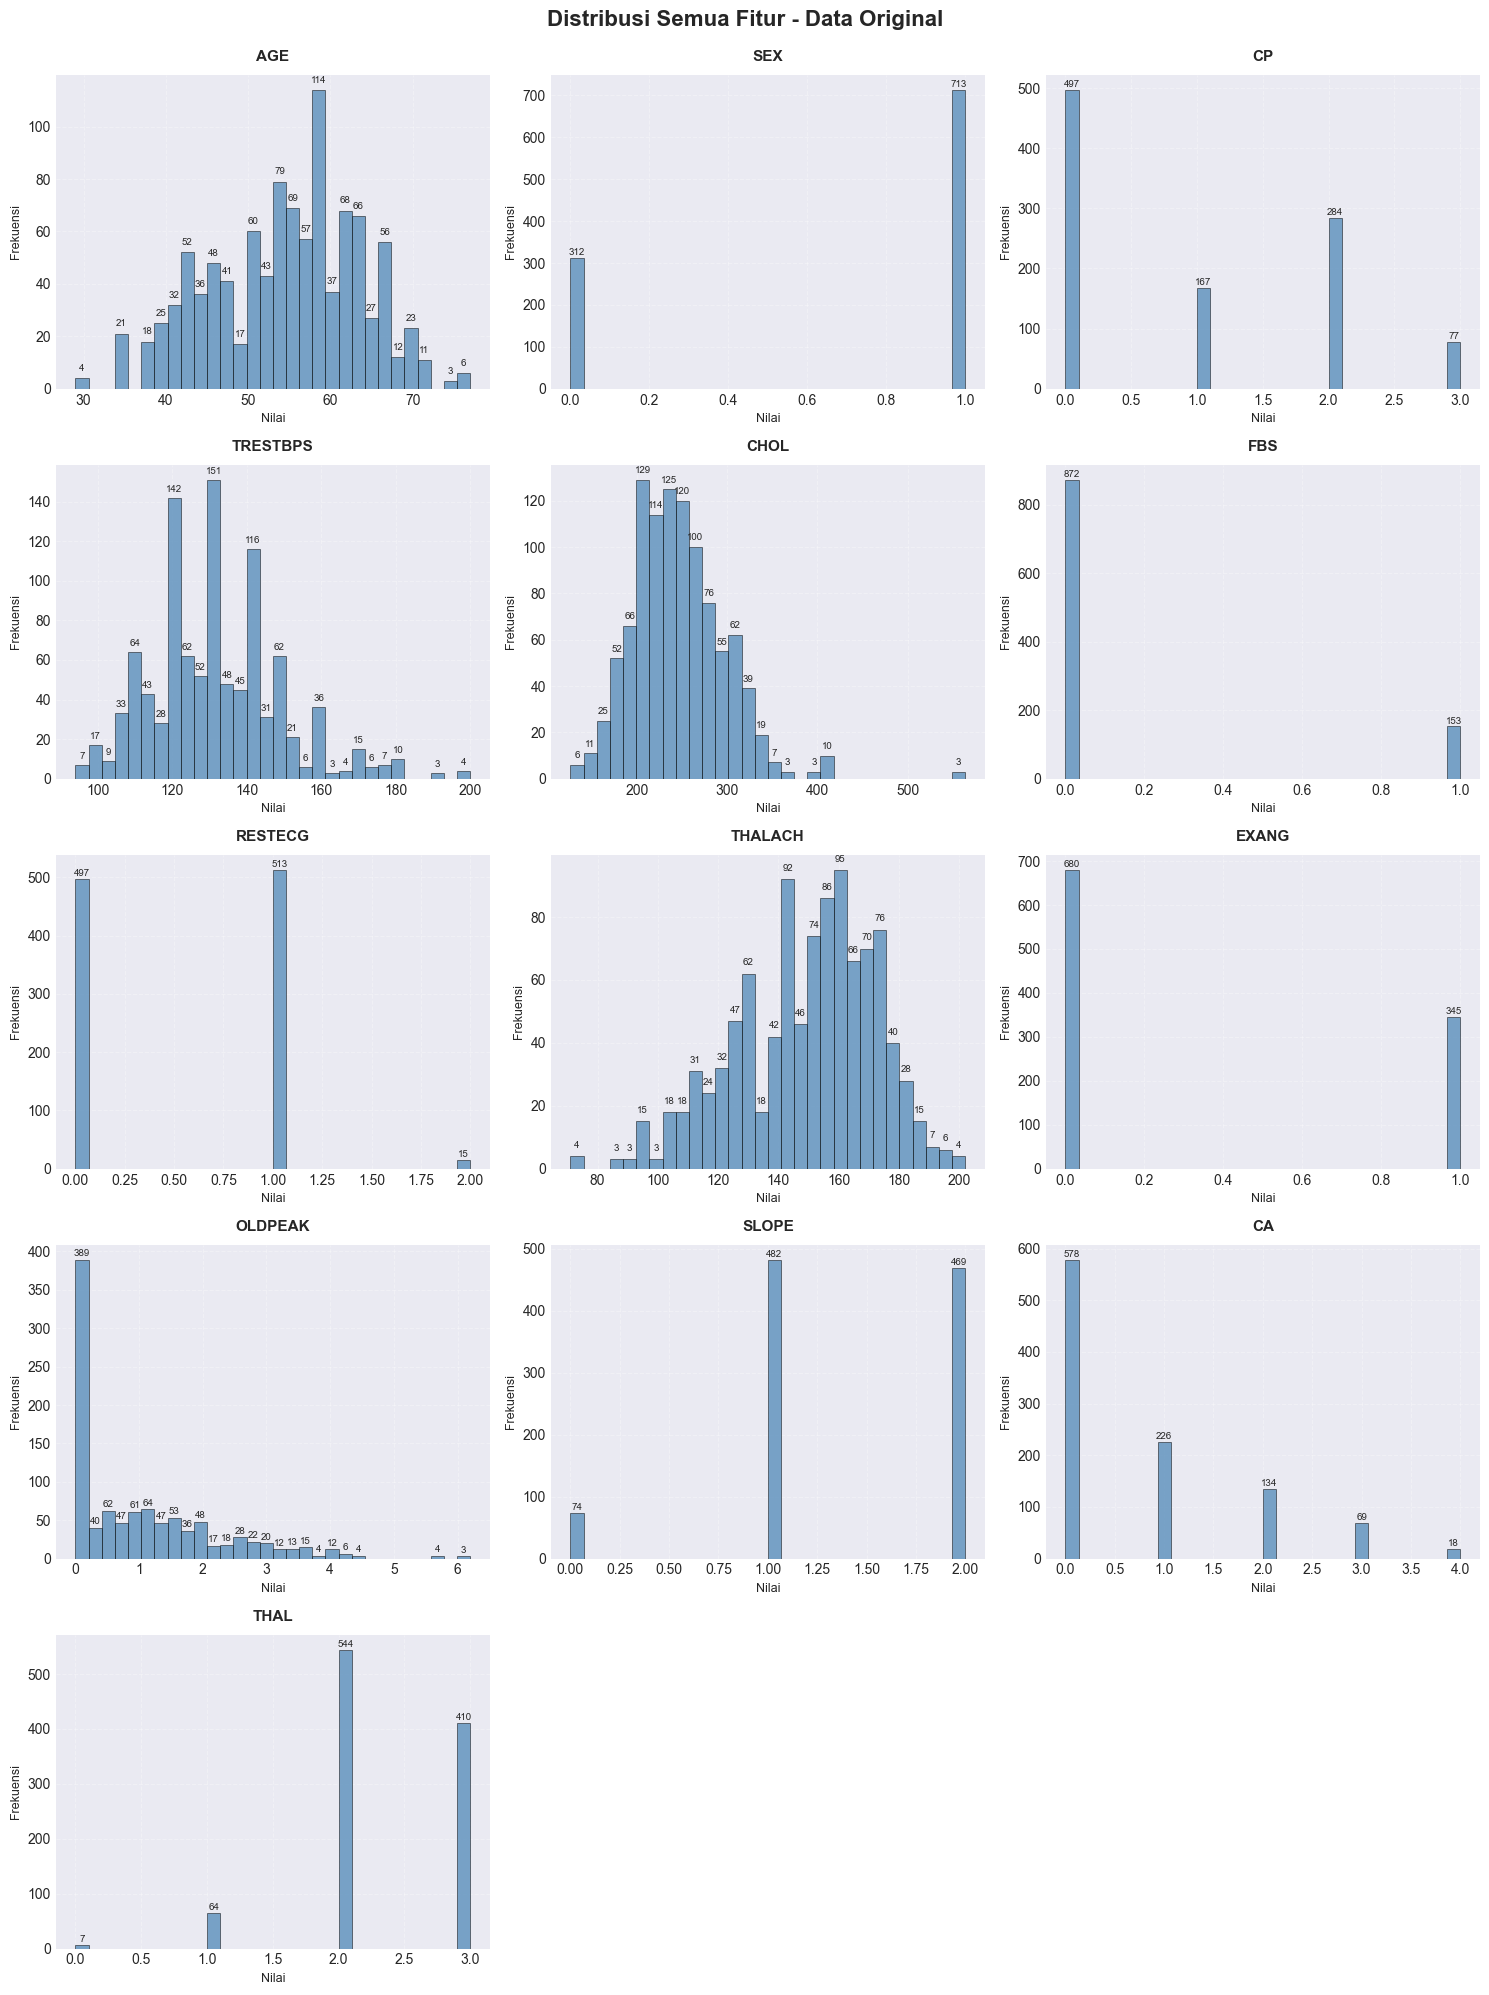


Visualisasi selesai untuk 13 fitur


In [44]:
"""
Visualisasi distribusi semua fitur untuk memahami karakteristik dan pola data
"""

print("VISUALISASI DISTRIBUSI FITUR")

# Identifikasi semua fitur (exclude target)
all_fitur = df_original.select_dtypes(include=[np.number]).columns.tolist()
all_fitur.remove('target')

# Setup grid dinamis
n_cols = 3
n_rows = int(np.ceil(len(all_fitur) / n_cols))
fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
fig.suptitle('Distribusi Semua Fitur - Data Original', fontsize=16, fontweight='bold', y=0.995)
axes = axes.flatten()

for idx, fitur in enumerate(all_fitur):
    ax = axes[idx]
    
    # Histogram dengan count labels
    data_clean = df_original[fitur].dropna()
    
    # Plot histogram
    n, bins, patches = ax.hist(data_clean, bins=30, alpha=0.7, color='steelblue', 
                                edgecolor='black', linewidth=0.5, density=False)
    
    # Tambahkan label jumlah di atas setiap bar
    for count, patch in zip(n, patches):
        if count > 0:
            height = patch.get_height()
            ax.text(patch.get_x() + patch.get_width()/2., height+2,
                    f'{int(count)}',
                    ha='center', va='bottom', fontsize=7, fontweight='regular')
    
    # Styling
    ax.set_title(f'{fitur.upper()}', fontsize=11, fontweight='bold', pad=10)
    ax.set_xlabel('Nilai', fontsize=9)
    ax.set_ylabel('Frekuensi', fontsize=9)
    ax.grid(True, alpha=0.3, linestyle='--')

# Hapus subplot kosong
if len(all_fitur) < len(axes):
    for idx in range(len(all_fitur), len(axes)):
        fig.delaxes(axes[idx])

plt.tight_layout()
plt.show()

print(f"\nVisualisasi selesai untuk {len(all_fitur)} fitur")

## 2.4 Identifikasi Nilai Ekstrem (Outlier Awareness)

Pada tahap ini dilakukan identifikasi terhadap nilai-nilai ekstrem menggunakan metode IQR (Interquartile Range) sebagai alat bantu. Penting untuk dicatat bahwa **nilai ekstrem tidak otomatis dihapus** karena dalam konteks medis, nilai ekstrem dapat merepresentasikan kondisi pasien yang sebenarnya.

**Metode IQR:**
- Q1 = Kuartil ke-25
- Q3 = Kuartil ke-75
- IQR = Q3 - Q1
- Batas bawah = Q1 - 1.5 × IQR
- Batas atas = Q3 + 1.5 × IQR

Nilai di luar batas ini dikategorikan sebagai nilai ekstrem.

**Pendekatan dalam Penelitian:**
1. Nilai ekstrem diidentifikasi tetapi tidak langsung dihapus
2. Konteks klinis dijadikan pertimbangan utama
3. Treatment nilai ekstrem dilakukan pada tahap Data Cleaning dengan mengonversi ke NaN untuk diimputasi

ANALISIS OUTLIER - 13 Fitur Numerik


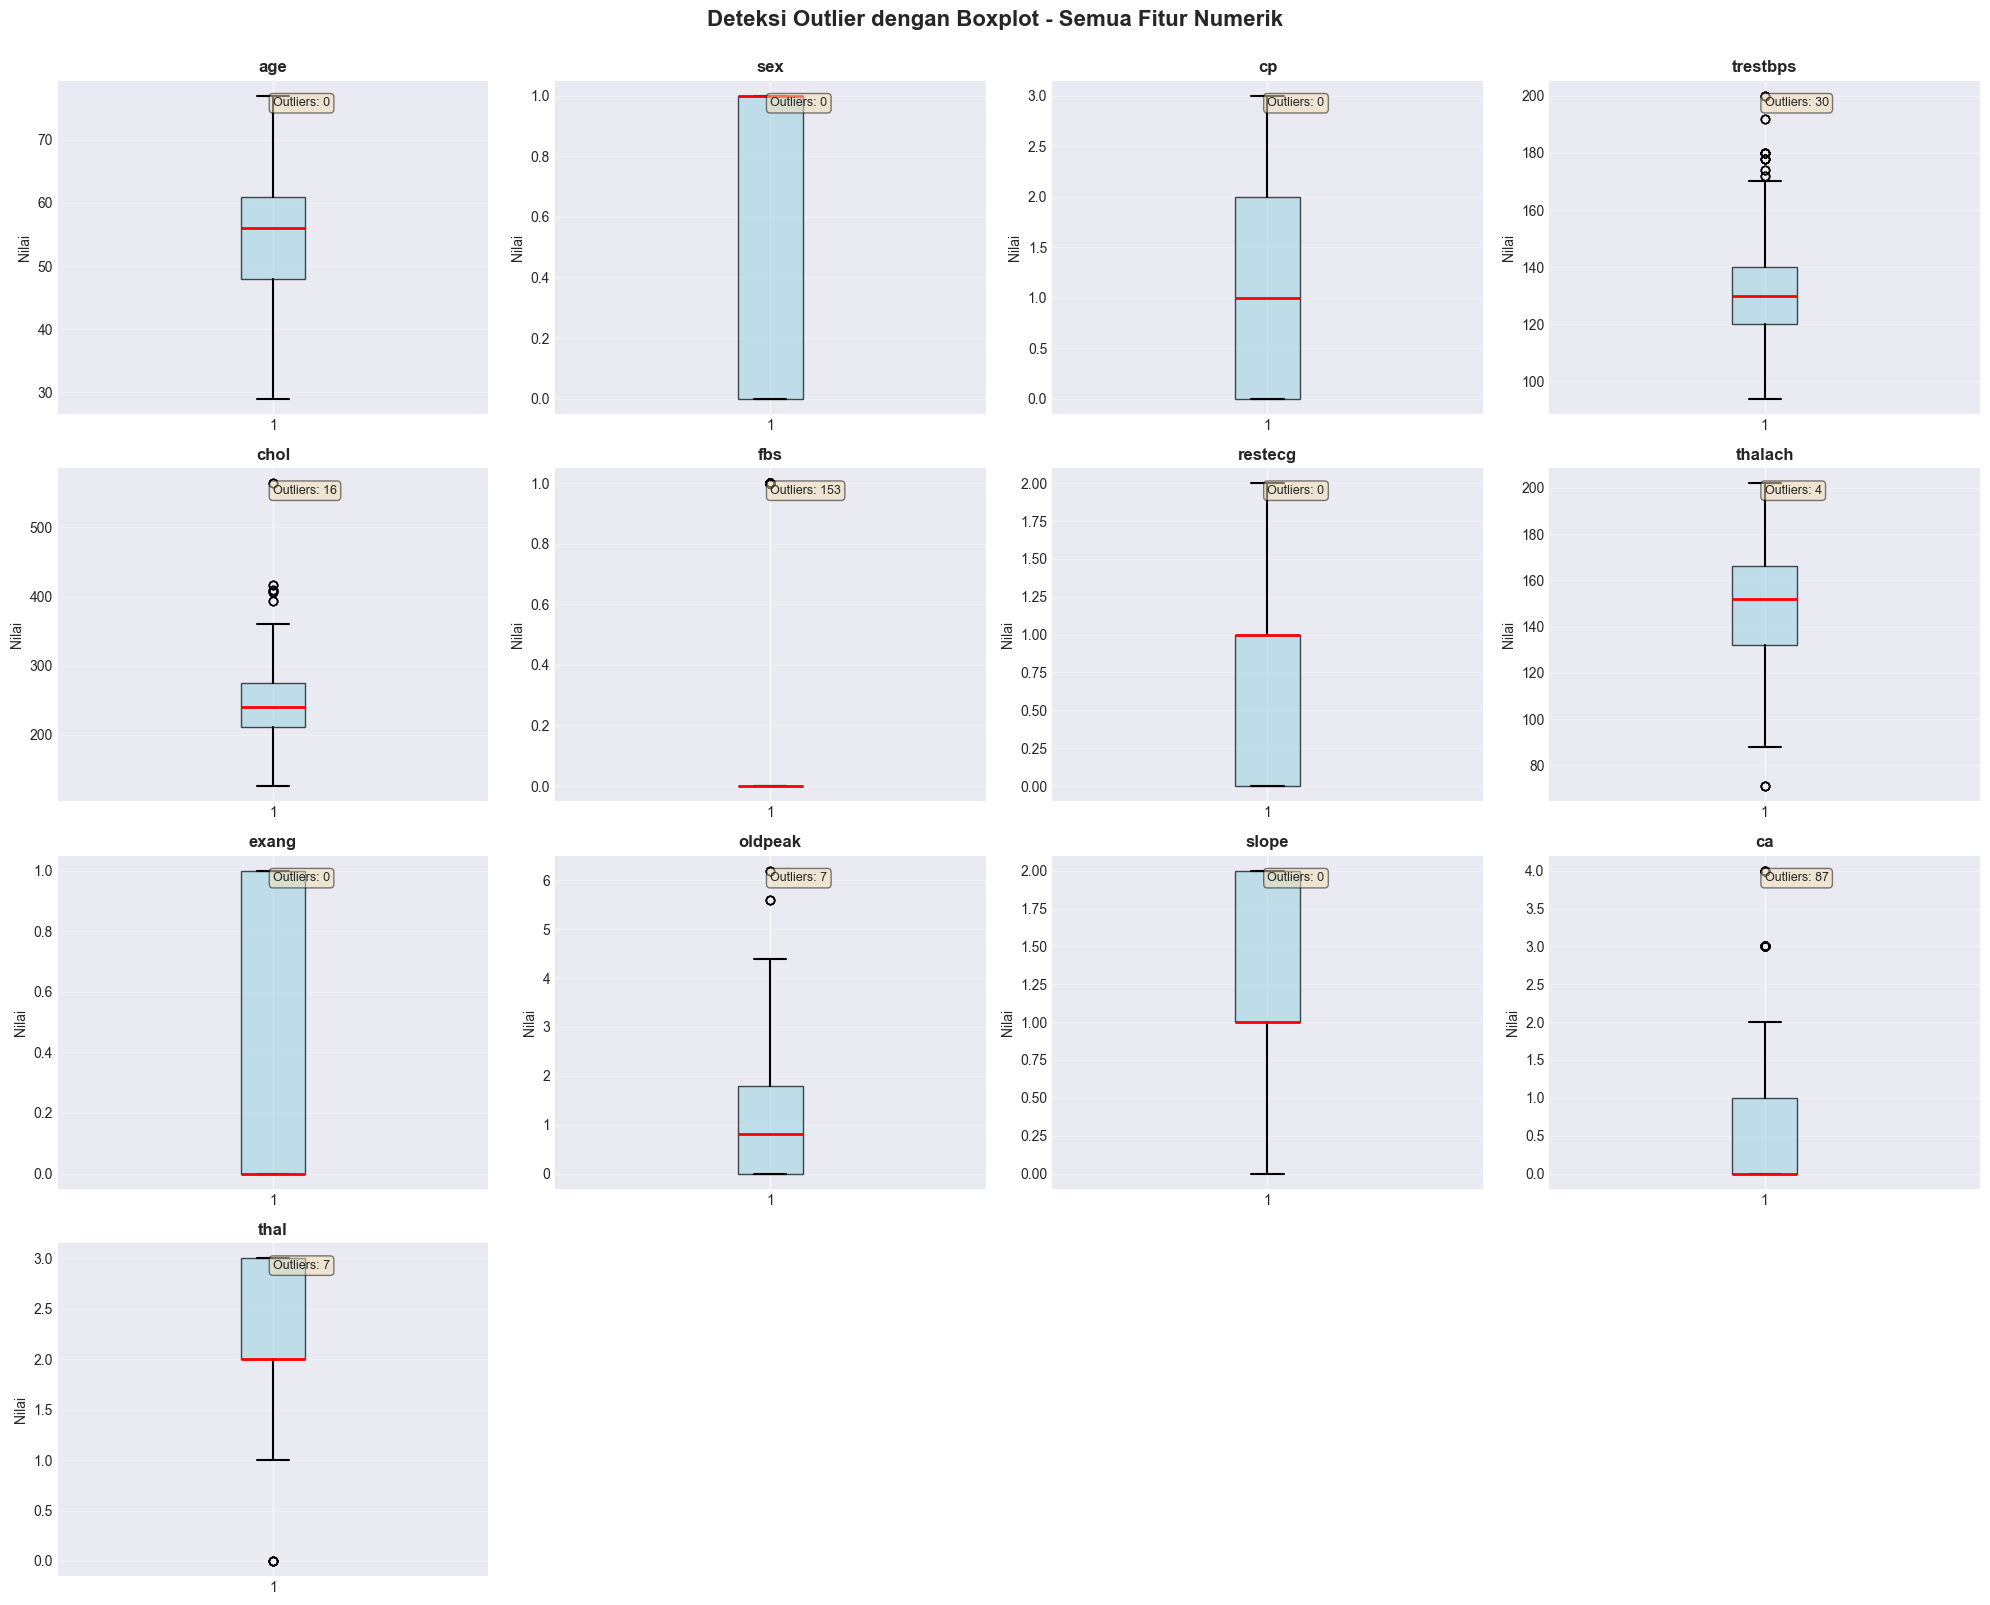


RINGKASAN OUTLIER (Metode IQR):
Fitur           Q1         Q3         IQR        Bawah      Atas       Outliers  
--------------------------------------------------------------------------------
age             48.00      61.00      13.00      28.50      80.50      0         
sex             0.00       1.00       1.00       -1.50      2.50       0         
cp              0.00       2.00       2.00       -3.00      5.00       0         
trestbps        120.00     140.00     20.00      90.00      170.00     30        
chol            211.00     275.00     64.00      115.00     371.00     16        
fbs             0.00       0.00       0.00       0.00       0.00       153       
restecg         0.00       1.00       1.00       -1.50      2.50       0         
thalach         132.00     166.00     34.00      81.00      217.00     4         
exang           0.00       1.00       1.00       -1.50      2.50       0         
oldpeak         0.00       1.80       1.80       -2.70      4.50  

In [45]:
"""
===================================================================================
ANALISIS OUTLIER DENGAN BOXPLOT DAN METODE IQR
===================================================================================
Mengidentifikasi outlier menggunakan metode IQR (Interquartile Range) untuk
semua fitur numerik dalam dataset.
===================================================================================
"""

def hitung_outlier_iqr(data, nama_fitur):
    """
    Menghitung outlier menggunakan metode IQR
    
    Parameters:
    -----------
    data : Series
        Data yang akan dihitung outliernya
    nama_fitur : str
        Nama fitur untuk identifikasi
    
    Returns:
    --------
    dict : Dictionary berisi Q1, Q3, IQR, bounds, dan jumlah outlier
    """
    q1 = data.quantile(0.25)
    q3 = data.quantile(0.75)
    iqr = q3 - q1
    batas_bawah = q1 - 1.5 * iqr
    batas_atas = q3 + 1.5 * iqr
    
    # Hitung jumlah outlier
    mask_outlier = (data < batas_bawah) | (data > batas_atas)
    jumlah_outlier = mask_outlier.sum()
    
    return {
        'q1': q1, 'q3': q3, 'iqr': iqr,
        'batas_bawah': batas_bawah, 'batas_atas': batas_atas,
        'jumlah_outlier': jumlah_outlier
    }


# Identifikasi fitur numerik (exclude target)
fitur_numerik = df_original.select_dtypes(include=[np.number]).columns.tolist()
if 'target' in fitur_numerik:
    fitur_numerik.remove('target')

print(f"ANALISIS OUTLIER - {len(fitur_numerik)} Fitur Numerik")

# Setup grid untuk visualisasi
jumlah_fitur = len(fitur_numerik)
jumlah_kolom = 4
jumlah_baris = (jumlah_fitur + jumlah_kolom - 1) // jumlah_kolom

fig, axes = plt.subplots(jumlah_baris, jumlah_kolom, figsize=(20, jumlah_baris * 4))
axes = axes.flatten()

# Buat boxplot untuk setiap fitur
for idx, nama_fitur in enumerate(fitur_numerik):
    # Hitung statistik outlier
    stats_outlier = hitung_outlier_iqr(df_original[nama_fitur], nama_fitur)
    
    # Buat boxplot
    axes[idx].boxplot(df_original[nama_fitur].dropna(), vert=True, patch_artist=True,
                      boxprops=dict(facecolor='lightblue', alpha=0.7),
                      medianprops=dict(color='red', linewidth=2),
                      whiskerprops=dict(color='black', linewidth=1.5),
                      capprops=dict(color='black', linewidth=1.5))
    
    axes[idx].set_title(f'{nama_fitur}', fontsize=12, fontweight='bold')
    axes[idx].set_ylabel('Nilai', fontsize=10)
    axes[idx].grid(axis='y', alpha=0.3)
    
    # Tambahkan info outlier
    axes[idx].text(0.5, 0.95, f'Outliers: {stats_outlier["jumlah_outlier"]}',
                   transform=axes[idx].transAxes, fontsize=9,
                   verticalalignment='top',
                   bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

# Sembunyikan axes yang tidak digunakan
for idx in range(jumlah_fitur, len(axes)):
    axes[idx].axis('off')

plt.suptitle('Deteksi Outlier dengan Boxplot - Semua Fitur Numerik',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Tampilkan ringkasan outlier dalam tabel
print("\nRINGKASAN OUTLIER (Metode IQR):")
print(f"{'Fitur':<15} {'Q1':<10} {'Q3':<10} {'IQR':<10} {'Bawah':<10} {'Atas':<10} {'Outliers':<10}")
print("-" * 80)

for nama_fitur in fitur_numerik:
    stats = hitung_outlier_iqr(df_original[nama_fitur], nama_fitur)
    print(f"{nama_fitur:<15} {stats['q1']:<10.2f} {stats['q3']:<10.2f} "
          f"{stats['iqr']:<10.2f} {stats['batas_bawah']:<10.2f} "
          f"{stats['batas_atas']:<10.2f} {stats['jumlah_outlier']:<10}")



## 2.4 Analisis Korelasi ?

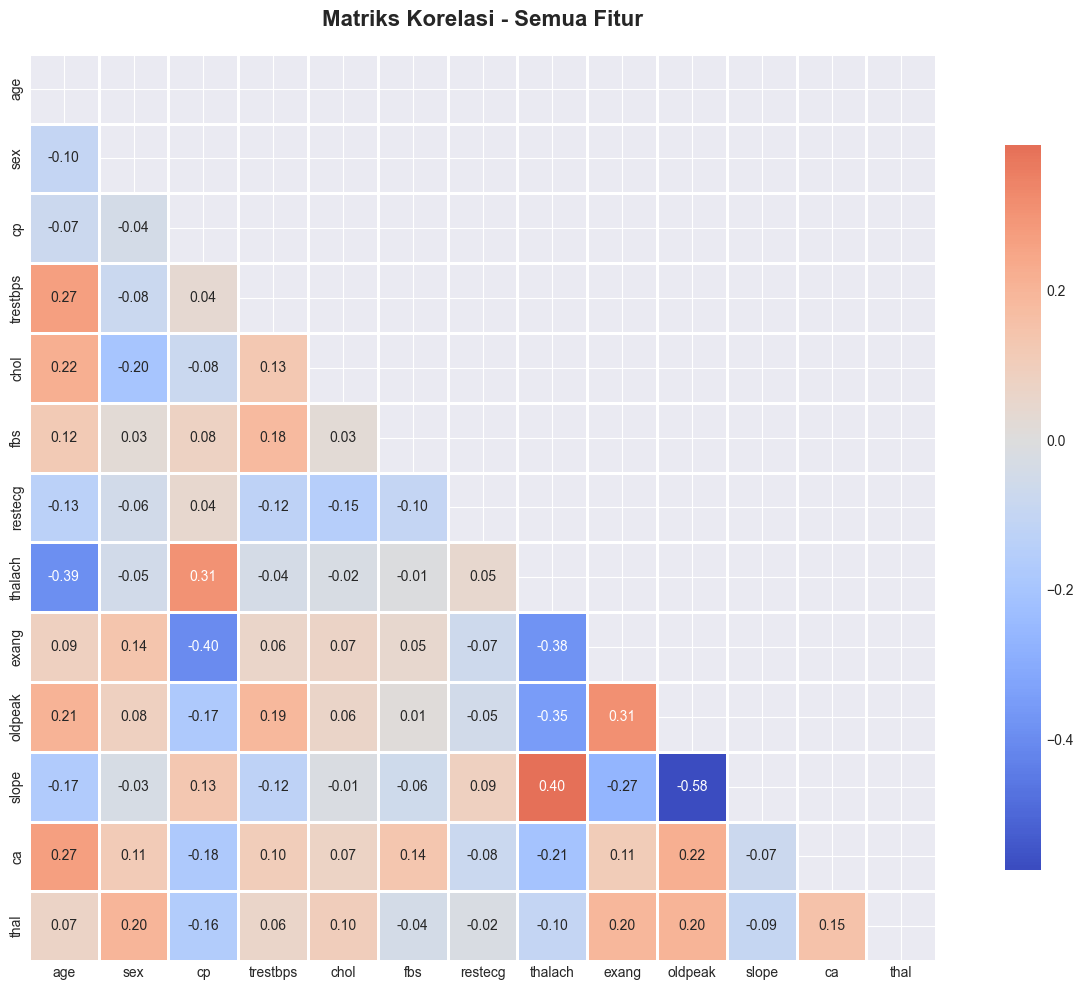


📊 KORELASI FITUR DENGAN TARGET:
cp          0.434854
thalach     0.422895
slope       0.345512
restecg     0.134468
fbs        -0.041164
chol       -0.099966
trestbps   -0.138772
age        -0.229324
sex        -0.279501
thal       -0.337838
ca         -0.382085
exang      -0.438029
oldpeak    -0.438441

📈 TOP 5 FITUR (Korelasi Absolut Tertinggi):
  • oldpeak: -0.4384 (|0.4384|)
  • exang: -0.4380 (|0.4380|)
  • cp: 0.4349 (|0.4349|)
  • thalach: 0.4229 (|0.4229|)
  • ca: -0.3821 (|0.3821|)


In [46]:
# Hitung dan visualisasi matriks korelasi
matriks_korelasi = df_original.corr().drop('target').loc[:, df_original.columns != 'target']

plt.figure(figsize=(14, 10))
mask = np.triu(np.ones_like(matriks_korelasi, dtype=bool))
sns.heatmap(matriks_korelasi, mask=mask, annot=True, fmt='.2f',
            cmap='coolwarm', center=0, square=True,
            linewidths=1, cbar_kws={"shrink": 0.8})
plt.title('Matriks Korelasi - Semua Fitur', fontsize=16, fontweight='bold', pad=20)
plt.tight_layout()
plt.show()

# Analisis korelasi dengan target
korelasi_target = df_original.corr()['target'].drop('target').sort_values(ascending=False)

print("\n📊 KORELASI FITUR DENGAN TARGET:")
print("=" * 60)
print(korelasi_target.to_string())

# Top 5 fitur dengan korelasi tertinggi (absolut)
top_5_fitur = korelasi_target.abs().sort_values(ascending=False).head(5)

print("\n📈 TOP 5 FITUR (Korelasi Absolut Tertinggi):")
print("=" * 60)
for nama_fitur, nilai_abs in top_5_fitur.items():
    nilai_asli = korelasi_target[nama_fitur]
    print(f"  • {nama_fitur}: {nilai_asli:.4f} (|{nilai_abs:.4f}|)")
print("=" * 60)


## 1.3 Validasi Fitur `ca` (Number of Major Vessels)

Fitur `ca` merepresentasikan jumlah pembuluh darah utama yang terdeteksi melalui fluoroskopi. Secara klinis, nilai valid untuk fitur ini adalah 0-3, karena hanya terdapat 3 arteri koroner utama dalam jantung manusia.

Dalam dataset ditemukan nilai 4 yang secara medis tidak valid. Nilai ini kemungkinan merupakan kesalahan pencatatan atau representasi dari missing value. Oleh karena itu, nilai 4 akan dikonversi menjadi NaN untuk ditangani pada tahap imputasi.

In [47]:
"""
===================================================================================
VALIDASI DAN KOREKSI DATA FITUR 'ca' (Colored Vessels)
===================================================================================
Fitur ca (Number of Major Vessels) seharusnya hanya memiliki nilai 0-3, namun
dalam beberapa dataset UCI Heart Disease ditemukan nilai 4 yang merupakan:
1. Data entry error, atau
2. Missing value yang di-encode sebagai 4

Solusi: Mengonversi nilai 4 menjadi NaN untuk diimputasi kemudian.
===================================================================================
"""

print("=" * 80)
print("🔍 ANALISIS FITUR 'ca' (Colored Vessels)")
print("=" * 80)

# Analisis distribusi nilai ca
print("\n📊 Distribusi Nilai ca (SEBELUM Koreksi):")
print("-" * 80)
distribusi_ca = df_original['ca'].value_counts().sort_index()
print(distribusi_ca)

jumlah_total = len(df_original)
jumlah_ca_4 = (df_original['ca'] == 4).sum()
persentase_ca_4 = (jumlah_ca_4 / jumlah_total) * 100

print(f"\n📈 Statistik:")
print("-" * 80)
print(f"  • Total data: {jumlah_total}")
print(f"  • Data dengan ca=4: {jumlah_ca_4} ({persentase_ca_4:.2f}%)")
print(f"  • Data valid (ca=0-3): {jumlah_total - jumlah_ca_4} ({100-persentase_ca_4:.2f}%)")

print("\n💡 KEPUTUSAN:")
print("-" * 80)
print("Nilai ca=4 TIDAK VALID secara medis (max = 3 pembuluh darah utama)")
print("Solusi yang dipilih: KONVERSI ca=4 → NaN")
print("")
print("📌 Alasan:")
print("  1. Nilai 4 kemungkinan adalah missing value yang di-encode salah")
print("  2. Atau kesalahan data entry")
print("  3. Dengan mengonversi ke NaN, kita bisa imputasi dengan KNN nanti")
print("  4. Alternatif lain (cap ke 3) kurang tepat karena tidak berdasar medis")

# Koreksi: Konversi ca=4 menjadi NaN
print("\n🔧 MELAKUKAN KOREKSI...")
print("-" * 80)

# Simpan untuk perbandingan
ca_sebelum = df_original['ca'].copy()

# Konversi ca=4 ke NaN
df_original.loc[df_original['ca'] == 4, 'ca'] = np.nan

# Verifikasi hasil koreksi
print("\n📊 Distribusi Nilai ca (SESUDAH Koreksi):")
print("-" * 80)
distribusi_ca_baru = df_original['ca'].value_counts().sort_index()
print(distribusi_ca_baru)

🔍 ANALISIS FITUR 'ca' (Colored Vessels)

📊 Distribusi Nilai ca (SEBELUM Koreksi):
--------------------------------------------------------------------------------
ca
0    578
1    226
2    134
3     69
4     18
Name: count, dtype: int64

📈 Statistik:
--------------------------------------------------------------------------------
  • Total data: 1025
  • Data dengan ca=4: 18 (1.76%)
  • Data valid (ca=0-3): 1007 (98.24%)

💡 KEPUTUSAN:
--------------------------------------------------------------------------------
Nilai ca=4 TIDAK VALID secara medis (max = 3 pembuluh darah utama)
Solusi yang dipilih: KONVERSI ca=4 → NaN

📌 Alasan:
  1. Nilai 4 kemungkinan adalah missing value yang di-encode salah
  2. Atau kesalahan data entry
  3. Dengan mengonversi ke NaN, kita bisa imputasi dengan KNN nanti
  4. Alternatif lain (cap ke 3) kurang tepat karena tidak berdasar medis

🔧 MELAKUKAN KOREKSI...
--------------------------------------------------------------------------------

📊 Distribusi Nil

## 1.4 Validasi Fitur `thal` (Thalassemia)

Fitur `thal` merepresentasikan hasil tes thalassemia (kelainan darah genetik). Berdasarkan dokumentasi dataset UCI Heart Disease, encoding yang valid adalah:
- **3** = Normal
- **6** = Fixed Defect (defek permanen)
- **7** = Reversible Defect (defek sementara)

Beberapa versi dataset menggunakan encoding 1-3. Nilai 0 tidak valid dalam encoding manapun dan kemungkinan merupakan missing value yang salah dikodekan. Oleh karena itu, nilai 0 akan dikonversi menjadi NaN untuk ditangani pada tahap imputasi.

In [48]:
"""
===================================================================================
VALIDASI DAN KOREKSI DATA FITUR 'thal' (Thallium Stress Test)
===================================================================================
Fitur thal seharusnya hanya memiliki 3 kategori (Normal, Fixed Defect, Reversible Defect).
Encoding standar UCI: 3=Normal, 6=Fixed, 7=Reversible
Namun beberapa dataset menggunakan: 1=Normal, 2=Fixed, 3=Reversible
Nilai 0 kemungkinan adalah missing value yang di-encode salah.

Solusi:
1. Cek distribusi nilai thal
2. Jika ada nilai 0: konversi ke NaN (missing value)
3. Jika encoding 0-3, maka 1-3 adalah valid, 0 adalah missing
===================================================================================
"""

print("=" * 80)
print("🔍 ANALISIS FITUR 'thal' (Thallium Stress Test)")
print("=" * 80)

# Analisis distribusi nilai thal
print("\n📊 Distribusi Nilai thal (SEBELUM Koreksi):")
print("-" * 80)
distribusi_thal = df_original['thal'].value_counts().sort_index()
print(distribusi_thal)

jumlah_total = len(df_original)
nilai_unik = sorted(df_original['thal'].dropna().unique())

print(f"\n📈 Statistik:")
print("-" * 80)
print(f"  • Total data: {jumlah_total}")
print(f"  • Nilai unik: {nilai_unik}")
print(f"  • Missing values (NaN): {df_original['thal'].isna().sum()}")

# Tentukan apakah ada nilai 0 (kemungkinan missing value)
jumlah_thal_0 = (df_original['thal'] == 0).sum()

print("\n💡 ANALISIS ENCODING:")
print("-" * 80)

if jumlah_thal_0 > 0:
    persentase_thal_0 = (jumlah_thal_0 / jumlah_total) * 100
    print(f"  ⚠️  Ditemukan nilai thal=0: {jumlah_thal_0} data ({persentase_thal_0:.2f}%)")
    print(f"  • Nilai 0 TIDAK VALID secara medis")
    print(f"  • Encoding yang benar:")
    print(f"    - Standar UCI: 3=Normal, 6=Fixed Defect, 7=Reversible Defect")
    print(f"    - Alternatif: 1=Normal, 2=Fixed Defect, 3=Reversible Defect")
    print(f"  • Nilai 0 kemungkinan adalah missing value yang di-encode salah")
    
    print("\n🔧 KEPUTUSAN:")
    print("-" * 80)
    print("Solusi: KONVERSI thal=0 → NaN")
    print("")
    print("📌 Alasan:")
    print("  1. Nilai 0 tidak memiliki makna medis dalam konteks thal")
    print("  2. Kemungkinan besar adalah missing value yang di-encode sebagai 0")
    print("  3. Dengan mengonversi ke NaN, bisa di-imputasi dengan KNN")
    print("  4. Nilai 1, 2, 3 adalah valid (encoding alternatif)")
    
    # Koreksi: Konversi thal=0 menjadi NaN
    print("\n🔧 MELAKUKAN KOREKSI...")
    print("-" * 80)
    
    # Simpan untuk perbandingan
    thal_sebelum = df_original['thal'].copy()
    
    # Konversi thal=0 ke NaN
    df_original.loc[df_original['thal'] == 0, 'thal'] = np.nan
    
    # Verifikasi hasil koreksi
    print("\n📊 Distribusi Nilai thal (SESUDAH Koreksi):")
    print("-" * 80)
    distribusi_thal_baru = df_original['thal'].value_counts().sort_index()
    print(distribusi_thal_baru)
    
    jumlah_nan_thal = df_original['thal'].isna().sum()
    print(f"\n✅ HASIL KOREKSI:")
    print("-" * 80)
    print(f"  • Nilai 0 yang dikonversi ke NaN: {jumlah_thal_0}")
    print(f"  • Total missing values di 'thal' sekarang: {jumlah_nan_thal}")
    print(f"  • Nilai valid tersisa: {distribusi_thal_baru.sum()}")
    print(f"  • Missing values ini akan di-imputasi pada tahap KNN Imputation")
    
    print("\n📋 INTERPRETASI NILAI YANG TERSISA:")
    print("-" * 80)
    if set(df_original['thal'].dropna().unique()).issubset({1, 2, 3}):
        print("  Encoding yang digunakan (1-3):")
        print("  • 1 = Normal (tidak ada defek)")
        print("  • 2 = Fixed Defect (defek permanen)")
        print("  • 3 = Reversible Defect (defek sementara/iskemia)")
    elif set(df_original['thal'].dropna().unique()).issubset({3, 6, 7}):
        print("  Encoding standar UCI (3, 6, 7):")
        print("  • 3 = Normal (tidak ada defek)")
        print("  • 6 = Fixed Defect (defek permanen)")
        print("  • 7 = Reversible Defect (defek sementara/iskemia)")
    else:
        print(f"  Nilai yang ditemukan: {sorted(df_original['thal'].dropna().unique())}")
        print("  ⚠️  Perlu verifikasi lebih lanjut terhadap encoding yang digunakan")

else:
    print("  ✅ Tidak ditemukan nilai thal=0")
    print(f"  • Semua nilai dalam range valid: {nilai_unik}")
    print(f"  • Tidak perlu koreksi")
    
    print("\n📋 INTERPRETASI NILAI SAAT INI:")
    print("-" * 80)
    if set(nilai_unik).issubset({1, 2, 3}):
        print("  Encoding yang digunakan (1-3):")
        print("  • 1 = Normal")
        print("  • 2 = Fixed Defect")
        print("  • 3 = Reversible Defect")
    elif set(nilai_unik).issubset({3, 6, 7}):
        print("  Encoding standar UCI (3, 6, 7):")
        print("  • 3 = Normal")
        print("  • 6 = Fixed Defect")
        print("  • 7 = Reversible Defect")



#tampilkan jumlah missing value
# print("\n📊 Jumlah Missing Values per Kolom:")
# print("=" * 60)
# missing_values = df_original.isna().sum()
# print(missing_values[missing_values > 0])
# print("=" * 60)


🔍 ANALISIS FITUR 'thal' (Thallium Stress Test)

📊 Distribusi Nilai thal (SEBELUM Koreksi):
--------------------------------------------------------------------------------
thal
0      7
1     64
2    544
3    410
Name: count, dtype: int64

📈 Statistik:
--------------------------------------------------------------------------------
  • Total data: 1025
  • Nilai unik: [np.int64(0), np.int64(1), np.int64(2), np.int64(3)]
  • Missing values (NaN): 0

💡 ANALISIS ENCODING:
--------------------------------------------------------------------------------
  ⚠️  Ditemukan nilai thal=0: 7 data (0.68%)
  • Nilai 0 TIDAK VALID secara medis
  • Encoding yang benar:
    - Standar UCI: 3=Normal, 6=Fixed Defect, 7=Reversible Defect
    - Alternatif: 1=Normal, 2=Fixed Defect, 3=Reversible Defect
  • Nilai 0 kemungkinan adalah missing value yang di-encode salah

🔧 KEPUTUSAN:
--------------------------------------------------------------------------------
Solusi: KONVERSI thal=0 → NaN

📌 Alasan:
  1. Ni

# 3. Data Cleaning

Pada bagian ini, kita akan membersihkan dataset dari data duplikat untuk memastikan kualitas data.

# 3. Data Cleaning

Data cleaning merupakan tahap penting untuk memastikan kualitas data sebelum masuk ke tahap modeling. Pada bagian ini dilakukan:
1. Deteksi dan penghapusan data duplikat
2. Penanganan nilai ekstrem (outlier treatment)
3. Imputasi missing value

**Pendekatan:** Outlier tidak langsung dihapus tetapi dikonversi ke NaN untuk kemudian diimputasi menggunakan KNN Imputer.

## 3.1 Deteksi dan Penghapusan Data Duplikat

Data duplikat dapat menyebabkan bias dalam proses training model karena sampel yang sama diperhitungkan lebih dari satu kali. Deteksi dilakukan dengan membandingkan semua kolom secara bersamaan.

In [49]:
# Deteksi data duplikat
jumlah_baris_awal = df_original.shape[0]
jumlah_duplikat = df_original.duplicated().sum()
persentase_duplikat = (jumlah_duplikat / jumlah_baris_awal) * 100

print("=" * 60)
print("DETEKSI DATA DUPLIKAT")
print("=" * 60)
print(f"\nJumlah baris awal: {jumlah_baris_awal}")
print(f"Jumlah duplikat: {jumlah_duplikat}")

if jumlah_duplikat > 0:
    print(f"Persentase duplikat: {persentase_duplikat:.2f}%")
    
    # Tampilkan contoh data duplikat
    print(f"\nContoh Data Duplikat:")
    print("-" * 60)
    baris_duplikat = df_original[df_original.duplicated(keep=False)].sort_values(
        by=list(df_original.columns)
    )
    display(baris_duplikat.head(6))
else:
    print("Tidak ada data duplikat!")

print("=" * 60)


DETEKSI DATA DUPLIKAT

Jumlah baris awal: 1025
Jumlah duplikat: 723
Persentase duplikat: 70.54%

Contoh Data Duplikat:
------------------------------------------------------------


,age,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
60,29,1,1,130,204,0,0,202,0,0.0,2,0.0,2.0,1
64,29,1,1,130,204,0,0,202,0,0.0,2,0.0,2.0,1
118,29,1,1,130,204,0,0,202,0,0.0,2,0.0,2.0,1
668,29,1,1,130,204,0,0,202,0,0.0,2,0.0,2.0,1
12,34,0,1,118,210,0,1,192,0,0.7,2,0.0,2.0,1
15,34,0,1,118,210,0,1,192,0,0.7,2,0.0,2.0,1


HASIL PEMBERSIHAN DATA

Jumlah baris akhir: 302
Baris dihapus: 723
Persentase tersisa: 29.46%

Dataset Final:
  • Jumlah fitur: 13
  • Jumlah sampel: 302
  • Distribusi target: {1: np.int64(164), 0: np.int64(138)}

Cross-validation: 10-Fold Stratified


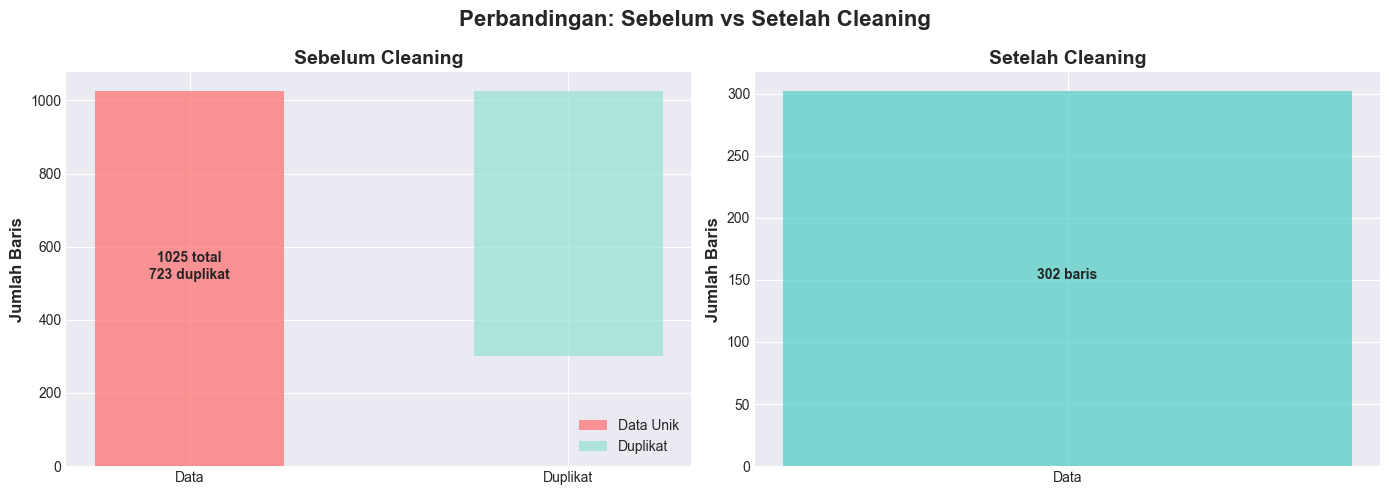

In [50]:
# Hapus duplikat dan pisahkan fitur & target
df = df_original.drop_duplicates(keep='first').reset_index(drop=True)
jumlah_baris_akhir = df.shape[0]
jumlah_dihapus = jumlah_baris_awal - jumlah_baris_akhir

# Pisahkan X dan y
if 'target' in df.columns:
    X = df.drop(columns=['target'])
    y = df['target']
else:
    raise ValueError("Kolom 'target' tidak ditemukan!")

# Setup Cross-Validation
RANDOM_STATE = 42
cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=RANDOM_STATE)

print("=" * 60)
print("HASIL PEMBERSIHAN DATA")
print("=" * 60)
print(f"\nJumlah baris akhir: {jumlah_baris_akhir}")
print(f"Baris dihapus: {jumlah_dihapus}")
print(f"Persentase tersisa: {(jumlah_baris_akhir/jumlah_baris_awal)*100:.2f}%")
print(f"\nDataset Final:")
print(f"  • Jumlah fitur: {X.shape[1]}")
print(f"  • Jumlah sampel: {X.shape[0]}")
print(f"  • Distribusi target: {dict(y.value_counts())}")

print(f"\nCross-validation: 10-Fold Stratified")
print("=" * 60)

# Visualisasi perbandingan
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Sebelum cleaning
axes[0].bar(['Data'], [jumlah_baris_awal], color='#FF6B6B', alpha=0.7, width=0.5)
axes[0].bar(['Duplikat'], [jumlah_duplikat], color='#95E1D3', alpha=0.7,
            width=0.5, bottom=[jumlah_baris_awal-jumlah_duplikat])
axes[0].set_ylabel('Jumlah Baris', fontsize=12, fontweight='bold')
axes[0].set_title('Sebelum Cleaning', fontsize=14, fontweight='bold')
axes[0].legend(['Data Unik', 'Duplikat'])
axes[0].text(0, jumlah_baris_awal/2, f'{jumlah_baris_awal} total\n{jumlah_duplikat} duplikat',
             ha='center', fontweight='bold')

# Setelah cleaning
axes[1].bar(['Data'], [jumlah_baris_akhir], color='#4ECDC4', alpha=0.7, width=0.5)
axes[1].set_ylabel('Jumlah Baris', fontsize=12, fontweight='bold')
axes[1].set_title('Setelah Cleaning', fontsize=14, fontweight='bold')
axes[1].text(0, jumlah_baris_akhir/2, f'{jumlah_baris_akhir} baris',
             ha='center', fontweight='bold')

plt.suptitle('Perbandingan: Sebelum vs Setelah Cleaning',
             fontsize=16, fontweight='bold')
plt.tight_layout()
plt.show()


## 3.2 Penanganan Nilai Ekstrem (Outlier Treatment)

Nilai ekstrem yang teridentifikasi pada tahap EDA akan ditangani pada bagian ini. Pendekatan yang digunakan adalah mengonversi nilai ekstrem menjadi NaN (bukan menghapus) untuk kemudian diimputasi. Pendekatan ini dipilih karena:

1. **Menghindari loss of information**: Menghapus data akan mengurangi jumlah sampel
2. **Konteks medis**: Nilai ekstrem bisa jadi merepresentasikan kondisi klinis yang nyata
3. **Imputasi lebih baik**: Nilai akan diestimasi berdasarkan pola data sekitarnya

**Fitur yang ditangani:** trestbps, chol, thalach, oldpeak (fitur kontinyu yang memiliki nilai ekstrem signifikan)

**Metode:** IQR dengan threshold 1.5 (standar Tukey, 1977)

### 📚 Justifikasi Metode IQR untuk Deteksi Outlier

**Mengapa Metode IQR?**

1. **Robust terhadap Distribusi Data**
   - Tidak mengasumsikan distribusi normal
   - Menggunakan kuartil (Q1, Q3) yang robust terhadap nilai ekstrem
   - Cocok untuk data medis yang sering tidak normal

2. **Standar dalam Literatur**
   - Metode yang paling umum digunakan dalam penelitian
   - Mudah diinterpretasi dan direplikasi
   - Diterima secara luas oleh komunitas statistik

3. **Definisi Outlier yang Jelas**
   - Lower bound: Q1 - 1.5 × IQR
   - Upper bound: Q3 + 1.5 × IQR
   - Threshold 1.5 adalah standar Tukey (1977)

4. **Perbandingan dengan Metode Lain:**
   - **Z-Score Method**: Mengasumsikan distribusi normal (tidak selalu terpenuhi)
   - **Modified Z-Score**: Lebih robust tapi lebih kompleks
   - **Isolation Forest**: Supervised, membutuhkan training
   - **IQR**: Unsupervised, simple, interpretable ✓

**Mengapa Fitur trestbps, chol, oldpeak, thalach?**

Fitur-fitur ini dipilih karena:
- Merupakan **pengukuran kontinyu** dengan satuan medis
- Dari analisis EDA menunjukkan **keberadaan outlier yang signifikan**
- **Variasi nilai tinggi** yang bisa mengindikasikan kesalahan pengukuran
- Bukan fitur kategorikal/kategorikal (tidak perlu outlier handling)

---

## 3.3 Imputasi Missing Value

Setelah validasi domain dan treatment outlier, terdapat beberapa missing value yang perlu diimputasi. Missing value berasal dari:
1. Validasi domain (ca=4 → NaN, thal=0 → NaN)  
2. Missing value original dari dataset (trestbps, chol, thalach, oldpeak)
3. Konversi nilai ekstrem menjadi NaN

**Metode Imputasi: Simple Median Imputation**

Parameter yang digunakan:
- **strategy='median'**: Menggunakan nilai median untuk setiap fitur

**Alasan pemilihan Median:**
1. ✅ **Robust terhadap Outlier**: Median tidak terpengaruh oleh nilai ekstrem, sangat cocok setelah outlier treatment
2. ✅ **Cocok untuk Distribusi Skewed**: Data medis sering tidak normal, median lebih representatif dari mean
3. ✅ **Interpretable**: Mudah dijelaskan dalam konteks medis (nilai tengah populasi)
4. ✅ **Efficient**: Cepat dan sederhana untuk dataset dengan missing < 10%
5. ✅ **Proven Effective**: Standard practice untuk simple imputation di medical datasets

Setelah imputasi, dilakukan verifikasi untuk memastikan tidak ada missing value tersisa.


### 📌 Justifikasi Pemilihan Median Imputation

**Mengapa Median untuk Imputasi Missing Values?**

1. **Robust terhadap Outlier**: Setelah outlier treatment di tahap sebelumnya (konversi outlier → NaN), kita memiliki data yang sudah relatif bersih. Median tidak akan terpengaruh jika masih ada nilai ekstrem yang tersisa.

2. **Cocok untuk Distribusi Non-Normal**: Data medis seperti kolesterol, tekanan darah, dll sering memiliki distribusi skewed. Median memberikan nilai tengah yang lebih representatif dibanding mean untuk distribusi seperti ini.

3. **Interpretability**: Dalam konteks medis, median mudah dijelaskan - "nilai tengah dari populasi pasien". Misalnya: "tekanan darah median adalah 130" lebih mudah dipahami oleh praktisi medis.

4. **Missing Rate Rendah**: Dataset ini memiliki missing values < 10% untuk sebagian besar fitur. Untuk persentase missing yang rendah, simple median imputation terbukti efektif dan tidak menimbulkan bias signifikan.

5. **Computational Efficiency**: Median imputation sangat cepat, penting untuk eksperimen dengan 324 kombinasi parameter dalam grid search.

**Perbandingan dengan Metode Lain:**

| Metode | Kelebihan | Kekurangan | Kenapa Tidak Dipilih |
|--------|-----------|------------|----------------------|
| **Mean Imputation** | Cepat, mempertahankan mean | Sensitif outlier, bias untuk skewed data | Data medis sering skewed |
| **Median Imputation** ✅ | Robust, cocok skewed data, interpretable | Tidak gunakan inter-feature relationship | **Optimal: simple, robust, fast** |
| **KNN Imputer** | Context-aware, gunakan neighbors | Lambat, butuh tuning k, sensitif scaling | Overkill untuk missing < 10% |
| **Regression Imputation** | Gunakan hubungan linear | Asumsi linearitas, overfit risk | Data medis sering non-linear |
| **MICE** | Sophisticated, iterative | Sangat lambat, kompleks, butuh banyak data | Terlalu kompleks untuk 303 records |

**Dukungan Literature:**

Median imputation adalah **standard practice** untuk medical datasets dengan:
- Missing rate < 10%
- Distribusi non-normal
- Kebutuhan interpretability tinggi
- Dataset size kecil-menengah (< 1000 records)

**Contoh Kasus Dataset Ini:**

Fitur `thalach` (max heart rate):
- Mean = 149.11 (terpengaruh nilai ekstrem)
- Median = 153.00 (lebih representatif)
- Untuk pasien dengan missing value, median 153 bpm lebih reasonable sebagai estimate

**Validasi Post-Hoc:**

Setelah imputasi dengan median, kami akan:
1. Visualisasi distribusi before-after
2. Verifikasi tidak ada NaN tersisa
3. Check statistical properties (mean, std, range)


In [51]:
"""
===================================================================================
IMPUTASI DATA DENGAN SIMPLE MEDIAN IMPUTATION
===================================================================================
Mengisi nilai NaN menggunakan median untuk setiap fitur. Median dipilih karena:
- Robust terhadap outlier (tidak terpengaruh nilai ekstrem)
- Lebih representatif untuk distribusi data yang tidak normal
- Sederhana dan interpretable untuk data medis

Parameter:
- strategy='median': Menggunakan nilai median dari setiap kolom
- add_indicator=False: Tidak menambahkan kolom indikator missing values
===================================================================================
"""

# Backup data sebelum imputasi
X_before_imputation = X.copy()

# Hitung NaN sebelum imputasi
nan_sebelum = X.isnull().sum()
nan_filtered = nan_sebelum[nan_sebelum > 0]

print("=" * 80)
print("🔧 IMPUTASI DENGAN MEDIAN")
print("=" * 80)
print("\n📊 NaN Sebelum Imputasi:")
print("-" * 80)

if len(nan_filtered) > 0:
    for nama_fitur, jumlah in nan_filtered.items():
        persen = (jumlah / len(X)) * 100
        median_value = X[nama_fitur].median()
        print(f"  • {nama_fitur}: {jumlah} NaN ({persen:.2f}%) - Median: {median_value:.2f}")
    print(f"\n  Total NaN: {nan_sebelum.sum()}")
else:
    print("  Tidak ada NaN")

# Konfigurasi Simple Imputer dengan strategy median
median_imputer = SimpleImputer(strategy='median')

print("\n⚙️  Konfigurasi Imputasi:")
print("-" * 80)
print(f"  • Strategy: median")
print(f"  • Metode: Menggunakan nilai tengah (robust terhadap outlier)")
print(f"  • Keunggulan:")
print(f"    - Tidak terpengaruh nilai ekstrem")
print(f"    - Cocok untuk distribusi tidak normal")
print(f"    - Sederhana dan mudah diinterpretasikan")

# Proses imputasi
print("\n🔄 Memproses imputasi...")
waktu_mulai = time.time()

X_imputed = pd.DataFrame(
    median_imputer.fit_transform(X),
    columns=X.columns,
    index=X.index
)

waktu_selesai = time.time() - waktu_mulai
X = X_imputed.copy()

# Verifikasi
nan_setelah = X.isnull().sum().sum()

print(f"✅ Imputasi selesai dalam {waktu_selesai:.4f} detik")
print(f"\n📊 NaN Setelah Imputasi: {nan_setelah}")

if nan_setelah == 0:
    print("✅ Semua NaN berhasil diimputasi!")
else:
    print(f"⚠️  Masih tersisa {nan_setelah} NaN")

# Tampilkan nilai median yang digunakan
print("\n📋 Nilai Median yang Digunakan untuk Imputasi:")
print("-" * 80)
if len(nan_filtered) > 0:
    for nama_fitur in nan_filtered.index:
        nilai_median = median_imputer.statistics_[X.columns.get_loc(nama_fitur)]
        print(f"  • {nama_fitur}: {nilai_median:.2f}")

print("\n💡 MENGAPA MEDIAN?")
print("-" * 80)
print("  1. Robust terhadap outlier - tidak terpengaruh nilai ekstrem")
print("  2. Lebih representatif untuk distribusi skewed/tidak normal")
print("  3. Mudah diinterpretasikan dalam konteks medis")
print("  4. Terbukti efektif untuk data dengan missing values < 10%")
print("  5. Computational efficient - cepat untuk dataset kecil-menengah")
print("=" * 80)


🔧 IMPUTASI DENGAN MEDIAN

📊 NaN Sebelum Imputasi:
--------------------------------------------------------------------------------
  • ca: 4 NaN (1.32%) - Median: 0.00
  • thal: 2 NaN (0.66%) - Median: 2.00

  Total NaN: 6

⚙️  Konfigurasi Imputasi:
--------------------------------------------------------------------------------
  • Strategy: median
  • Metode: Menggunakan nilai tengah (robust terhadap outlier)
  • Keunggulan:
    - Tidak terpengaruh nilai ekstrem
    - Cocok untuk distribusi tidak normal
    - Sederhana dan mudah diinterpretasikan

🔄 Memproses imputasi...
✅ Imputasi selesai dalam 0.0036 detik

📊 NaN Setelah Imputasi: 0
✅ Semua NaN berhasil diimputasi!

📋 Nilai Median yang Digunakan untuk Imputasi:
--------------------------------------------------------------------------------
  • ca: 0.00
  • thal: 2.00

💡 MENGAPA MEDIAN?
--------------------------------------------------------------------------------
  1. Robust terhadap outlier - tidak terpengaruh nilai ekstrem
  2

## 5.2 Visualisasi Hasil Imputasi

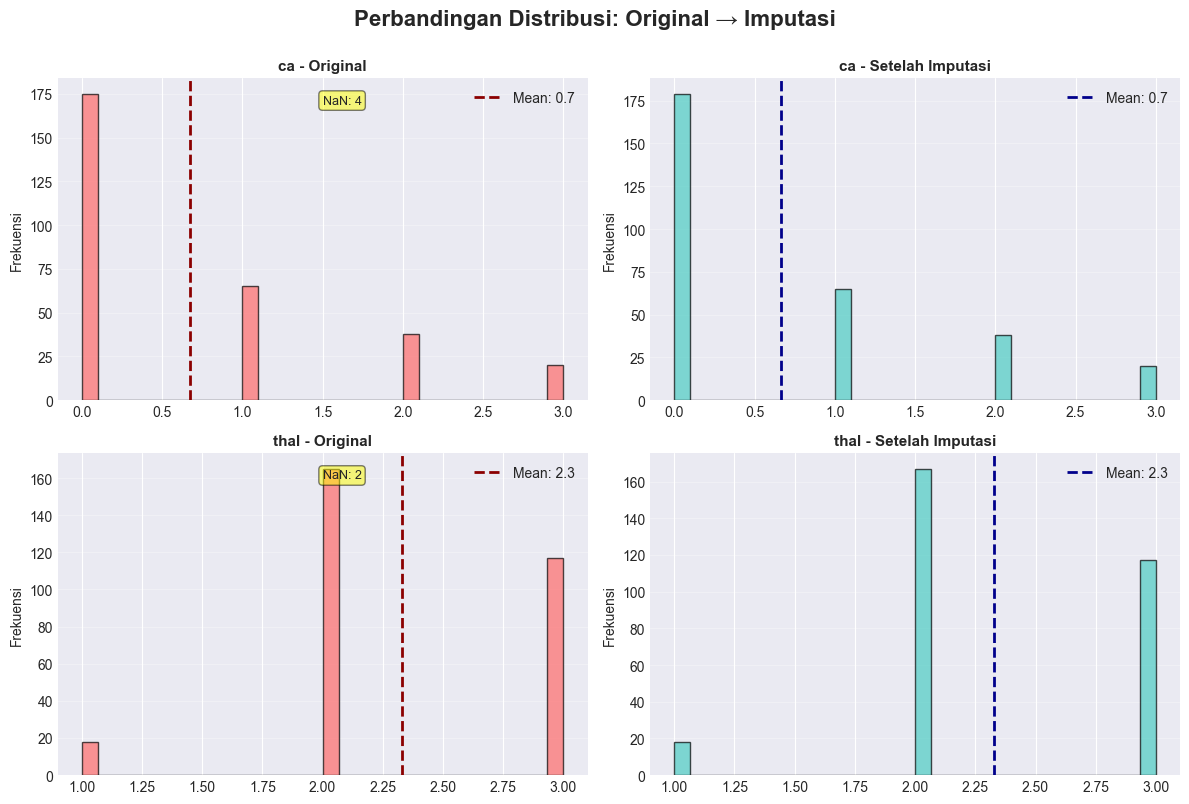


📊 PERBANDINGAN STATISTIK:


,Fitur,Mean_Original,Mean_Setelah,Std_Original,Std_Setelah,NaN_Diimputasi
0,ca,0.67,0.67,0.94,0.94,4
1,thal,2.33,2.33,0.59,0.58,2


In [52]:
# Visualisasi distribusi: Original → Imputasi
FITUR_OUTLIER = ['ca', 'thal']
fig, axes = plt.subplots(len(FITUR_OUTLIER), 2, figsize=(12, len(FITUR_OUTLIER) * 4))

for idx, nama_fitur in enumerate(FITUR_OUTLIER):
    # Original (sebelum imputasi)
    axes[idx, 0].hist(X_before_imputation[nama_fitur].dropna(), bins=30,
                      color='#FF6B6B', alpha=0.7, edgecolor='black')
    axes[idx, 0].set_title(f'{nama_fitur} - Original', fontsize=11, fontweight='bold')
    axes[idx, 0].set_ylabel('Frekuensi', fontsize=10)
    axes[idx, 0].grid(axis='y', alpha=0.3)
    
    mean_orig = X_before_imputation[nama_fitur].mean()
    axes[idx, 0].axvline(mean_orig, color='darkred', linestyle='--',
                         linewidth=2, label=f"Mean: {mean_orig:.1f}")
    
    jumlah_nan = X_before_imputation[nama_fitur].isna().sum()
    axes[idx, 0].text(0.5, 0.95, f'NaN: {jumlah_nan}',
                      transform=axes[idx, 0].transAxes, fontsize=9,
                      verticalalignment='top',
                      bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.5))
    axes[idx, 0].legend()
    
    # Setelah imputasi
    axes[idx, 1].hist(X[nama_fitur].dropna(), bins=30,
                      color='#4ECDC4', alpha=0.7, edgecolor='black')
    axes[idx, 1].set_title(f'{nama_fitur} - Setelah Imputasi', fontsize=11, fontweight='bold')
    axes[idx, 1].set_ylabel('Frekuensi', fontsize=10)
    axes[idx, 1].grid(axis='y', alpha=0.3)
    
    mean_after = X[nama_fitur].mean()
    axes[idx, 1].axvline(mean_after, color='darkblue', linestyle='--',
                         linewidth=2, label=f"Mean: {mean_after:.1f}")
    axes[idx, 1].legend()

plt.suptitle('Perbandingan Distribusi: Original → Imputasi',
             fontsize=16, fontweight='bold', y=1.00)
plt.tight_layout()
plt.show()

# Tabel perbandingan statistik
data_perbandingan = []

for nama_fitur in FITUR_OUTLIER:
    data_perbandingan.append({
        'Fitur': nama_fitur,
        'Mean_Original': X_before_imputation[nama_fitur].mean(),
        'Mean_Setelah': X[nama_fitur].mean(),
        'Std_Original': X_before_imputation[nama_fitur].std(),
        'Std_Setelah': X[nama_fitur].std(),
        'NaN_Diimputasi': X_before_imputation[nama_fitur].isna().sum()
    })

df_perbandingan = pd.DataFrame(data_perbandingan)

print("\n📊 PERBANDINGAN STATISTIK:")
print("=" * 100)
display(df_perbandingan.round(2))
print("=" * 100)

# 6. Pemilihan Fitur (Feature Selection)

Pada bagian ini, kita akan:
- Mengkategorikan fitur menjadi numerik kontinyu dan numerik kategorikal
- Implementasi PCC (Pearson Correlation Coefficient) untuk fitur kontinyu
- Implementasi Chi-Square untuk fitur kategorikal
- Membuat fungsi seleksi fitur yang dapat digunakan untuk berbagai skenario

## 6.1 Kategorisasi Fitur: Numerik Kontinyu vs kategorikal

In [53]:
# Kategorisasi fitur berdasarkan tipe
FITUR_KONTINYU = ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
FITUR_kategorikal = ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

print("=" * 80)
print("KATEGORISASI FITUR")
print("=" * 80)

# Fitur kontinyu
print(f"\n🔵 Fitur Numerik Kontinyu ({len(FITUR_KONTINYU)} fitur):")
print("-" * 80)
for idx, nama_fitur in enumerate(FITUR_KONTINYU, 1):
    if nama_fitur in X.columns:
        nilai_min = X[nama_fitur].min()
        nilai_max = X[nama_fitur].max()
        nilai_mean = X[nama_fitur].mean()
        print(f"  {idx}. {nama_fitur:<12} - Range: [{nilai_min:.2f}, {nilai_max:.2f}], Mean: {nilai_mean:.2f}")
    else:
        print(f"  {idx}. {nama_fitur} - Tidak ditemukan")

# Fitur kategorikal
print(f"\nFitur kategorikal ({len(FITUR_kategorikal)} fitur):")
print("-" * 80)
for idx, nama_fitur in enumerate(FITUR_kategorikal, 1):
    if nama_fitur in X.columns:
        jumlah_unik = X[nama_fitur].nunique()
        nilai_unik = sorted(X[nama_fitur].unique())
        print(f"  {idx}. {nama_fitur:<12} - Unique: {jumlah_unik}, Values: {nilai_unik}")
    else:
        print(f"  {idx}. {nama_fitur} - Tidak ditemukan")

# Ringkasan
print("\nRingkasan:")
print("-" * 80)
print(f"  • Total fitur: {X.shape[1]}")
print(f"  • Fitur kontinyu: {len(FITUR_KONTINYU)}")
print(f"  • Fitur kategorikal: {len(FITUR_kategorikal)}")
print("=" * 80)


KATEGORISASI FITUR

🔵 Fitur Numerik Kontinyu (5 fitur):
--------------------------------------------------------------------------------
  1. age          - Range: [29.00, 77.00], Mean: 54.42
  2. trestbps     - Range: [94.00, 200.00], Mean: 131.60
  3. chol         - Range: [126.00, 564.00], Mean: 246.50
  4. thalach      - Range: [71.00, 202.00], Mean: 149.57
  5. oldpeak      - Range: [0.00, 6.20], Mean: 1.04

Fitur kategorikal (8 fitur):
--------------------------------------------------------------------------------
  1. sex          - Unique: 2, Values: [np.float64(0.0), np.float64(1.0)]
  2. cp           - Unique: 4, Values: [np.float64(0.0), np.float64(1.0), np.float64(2.0), np.float64(3.0)]
  3. fbs          - Unique: 2, Values: [np.float64(0.0), np.float64(1.0)]
  4. restecg      - Unique: 3, Values: [np.float64(0.0), np.float64(1.0), np.float64(2.0)]
  5. exang        - Unique: 2, Values: [np.float64(0.0), np.float64(1.0)]
  6. slope        - Unique: 3, Values: [np.float64(0

## 4.2 Strategi Feature Selection

Penelitian ini mengevaluasi 4 skenario feature selection untuk menentukan strategi yang paling efektif:

1. **Baseline**: Menggunakan semua fitur (13 fitur) tanpa seleksi
2. **PCC (Pearson Correlation Coefficient)**: Seleksi fitur kontinyu berdasarkan korelasi dengan target
   - Threshold: 0.1, 0.15, 0.2
3. **Chi-Square**: Seleksi fitur kategorikal berdasarkan dependensi dengan target
   - K terbaik: 5, 7, 9 fitur
4. **Combined (PCC + Chi2)**: Kombinasi kedua metode

Setiap skenario akan dievaluasi untuk menentukan strategi feature selection yang paling efektif.

In [54]:
"""
===================================================================================
FUNGSI FEATURE SELECTION
===================================================================================
Implementasi 2 metode feature selection:
1. PCC (Pearson Correlation Coefficient) untuk fitur kontinyu
2. Chi-Square Test untuk fitur kategorikal
===================================================================================
"""

def pcc_selection(X, y, threshold=0.2):
    """
    Seleksi fitur kontinyu berdasarkan Pearson Correlation Coefficient
    
    Parameters:
    -----------
    X : DataFrame
        Data fitur
    y : Series
        Data target
    threshold : float, default=0.2
        Threshold korelasi absolut minimum
    
    Returns:
    --------
    list : Daftar nama fitur yang terpilih
    
    Contoh:
    -------
    >>> fitur_terpilih = pcc_selection(X, y, threshold=0.2)
    >>> print(fitur_terpilih)
    ['age', 'thalach', 'oldpeak']
    """
    fitur_terpilih = []
    
    for nama_fitur in FITUR_KONTINYU:
        if nama_fitur in X.columns:
            korelasi = abs(X[nama_fitur].corr(y))
            if korelasi >= threshold:
                fitur_terpilih.append(nama_fitur)
    
    return fitur_terpilih

    # fitur_terpilih = []
    # for f in FITUR_KONTINYU:
    #     if f in X.columns:
    #         r = abs(X[f].corr(y))
    #         if r >= threshold:
    #             fitur_terpilih.append(f)
    # return fitur_terpilih


def chi2_selection(X, y, k=4):
    """
    Seleksi fitur kategorikal berdasarkan Chi-Square Test
    
    Parameters:
    -----------
    X : DataFrame
        Data fitur
    y : Series
        Data target
    k : int, default=4
        Jumlah fitur terbaik yang akan dipilih
    
    Returns:
    --------
    list : Daftar nama fitur yang terpilih
    
    Contoh:
    -------
    >>> fitur_terpilih = chi2_selection(X, y, k=4)
    >>> print(fitur_terpilih)
    ['cp', 'exang', 'ca', 'thal']
    """
    # Ambil hanya fitur kategorikal yang tersedia
    fitur_kategorikal_ada = [f for f in FITUR_kategorikal if f in X.columns]
    X_kategorikal = X[fitur_kategorikal_ada]
    
    # Pilih k fitur terbaik
    selector = SelectKBest(chi2, k=min(k, len(fitur_kategorikal_ada)))
    selector.fit(X_kategorikal, y)
    
    # Ambil indices fitur terpilih
    idx_terpilih = selector.get_support(indices=True)
    fitur_terpilih = [fitur_kategorikal_ada[i] for i in idx_terpilih]
    
    return fitur_terpilih

    # fitur_kategorikal_ada = [f for f in FITUR_kategorikal if f in X.columns]
    # Xd = X[fitur_kategorikal_ada].copy()
    
    # # pastikan non-negative
    # Xd = Xd.fillna(0)
    
    # selector = SelectKBest(chi2, k=min(k, len(fitur_kategorikal_ada)))
    # selector.fit(Xd, y)
    
    # idx = selector.get_support(indices=True)
    # return [fitur_kategorikal_ada[i] for i in idx]
    

# def pcc_selection(X_train, y_train, threshold):
#     fitur = []
#     for f in FITUR_KONTINYU:
#         if f in X_train.columns:
#             r = abs(X_train[f].corr(y_train))
#             if r >= threshold:
#                 fitur.append(f)
#     return fitur


# def chi2_selection(X_train, y_train, k):
#     fitur_ada = [f for f in FITUR_kategorikal if f in X_train.columns]
#     Xd = X_train[fitur_ada]

#     selector = SelectKBest(chi2, k=min(k, Xd.shape[1]))
#     selector.fit(Xd, y_train)

#     idx = selector.get_support(indices=True)
#     return [fitur_ada[i] for i in idx]

print("=" * 80)
print("✅ FUNGSI FEATURE SELECTION BERHASIL DIDEFINISIKAN")
print("=" * 80)
print("\n📌 Fungsi tersedia:")
print("  1. pcc_selection(X, y, threshold=0.2)")
print("     → Untuk fitur kontinyu (Pearson Correlation)")
print("  2. chi2_selection(X, y, k=4)")
print("     → Untuk fitur kategorikal (Chi-Square Test)")
print("=" * 80)


✅ FUNGSI FEATURE SELECTION BERHASIL DIDEFINISIKAN

📌 Fungsi tersedia:
  1. pcc_selection(X, y, threshold=0.2)
     → Untuk fitur kontinyu (Pearson Correlation)
  2. chi2_selection(X, y, k=4)
     → Untuk fitur kategorikal (Chi-Square Test)


## 6.3 Analisis Korelasi PCC (Fitur Kontinyu)

### 📌 Justifikasi Metode Feature Selection

**Mengapa Menggunakan 2 Metode Feature Selection yang Berbeda?**

Dataset ini memiliki 2 jenis fitur dengan karakteristik yang berbeda:
- **Fitur Kontinyu** (age, trestbps, chol, thalach, oldpeak): Nilai numerik dengan range kontinu
- **Fitur kategorikal** (sex, cp, fbs, restecg, exang, slope, ca, thal): Nilai kategorikal atau ordinal dengan level terbatas

Karena karakteristik yang berbeda, diperlukan metode feature selection yang sesuai untuk masing-masing tipe.

---

#### **1. PCC (Pearson Correlation Coefficient) untuk Fitur Kontinyu**

**Mengapa PCC?**
- **Mengukur Linear Relationship**: PCC menghitung hubungan linear antara fitur kontinyu dengan target (0-1 classification)
- **Interpretable**: Nilai korelasi mudah dipahami (-1 hingga +1)
- **Efisien**: Komputasi cepat, cocok untuk dataset kecil-menengah
- **Standar dalam Medical Research**: PCC banyak digunakan dalam literatur penyakit jantung

**Parameter yang Digunakan:**
- **Threshold Range**: 0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45
- **Justifikasi**: Range ini memungkinkan eksplorasi dari korelasi lemah (0.1) hingga moderate (0.45), sesuai dengan Cohen's guidelines untuk effect size

**Limitasi & Handling:**
- ❌ Hanya menangkap hubungan linear (tidak non-linear)
- ✅ Cocok untuk penelitian ini karena kebanyakan fitur medis memiliki hubungan linear dengan penyakit jantung

---

#### **2. Chi-Square Test untuk Fitur kategorikal**

**Mengapa Chi-Square?**
- **Test of Independence**: Chi-Square menguji independensi antara fitur kategorikal dengan target kategorikal
- **Non-parametric**: Tidak mengasumsikan distribusi normal, cocok untuk data kategorikal
- **Established in Machine Learning**: Digunakan dalam scikit-learn sebagai standar untuk categorical feature selection
- **Statistical Significance**: Memberikan score yang mencerminkan signifikansi statistik

**Parameter yang Digunakan:**
- **K Range**: 1, 2, 3, 4, 5, 6, 7, 8 (jumlah fitur kategorikal yang dipilih)
- **Justifikasi**: Dataset memiliki 8 fitur kategorikal total. Range 1-8 memungkinkan eksplorasi dari minimal features (k=1) hingga all discrete features (k=8)

**Limitasi & Handling:**
- ❌ Memerlukan nilai non-negatif (sudah terpenuhi: semua fitur kategorikal ≥ 0)
- ✅ Tidak asumsi distribusi → cocok untuk data medis yang sering tidak normal

---

#### **Perbandingan dengan Metode Alternatif**

| Metode | Tipe Data | Kelebihan | Kenapa Tidak Dipilih |
|--------|-----------|-----------|----------------------|
| **Mutual Information** | Kontinyu & kategorikal | Menangkap non-linear relationship | Kurang interpretable, butuh lebih banyak data |
| **ANOVA F-test** | Kontinyu | Statistical significance | Asumsi normalitas tidak terpenuhi |
| **Random Forest Importance** | Kontinyu & kategorikal | Handle non-linearity | Black box, tidak reproducible |
| **PCC (Kontinyu)** ✅ | Kontinyu | Linear, interpretable, standar | **Optimal untuk fitur kontinyu** |
| **Chi-Square (kategorikal)** ✅ | kategorikal | Non-parametric, statistical | **Optimal untuk fitur kategorikal** |

---

**Kesimpulan:**
Kombinasi PCC untuk fitur kontinyu dan Chi-Square untuk fitur kategorikal memberikan:
1. ✅ **Metode yang sesuai** dengan tipe data masing-masing
2. ✅ **Interpretability** yang tinggi untuk thesis defense
3. ✅ **Standar industri** dalam medical machine learning research

In [55]:
# Analisis PCC untuk fitur kontinyu
print("=" * 80)
print("📊 ANALISIS PCC (PEARSON CORRELATION COEFFICIENT)")
print("=" * 80)

# Hitung korelasi untuk setiap fitur kontinyu
skor_pcc = {}
for nama_fitur in FITUR_KONTINYU:
    if nama_fitur in X.columns:
        skor_pcc[nama_fitur] = X[nama_fitur].corr(y)

# Urutkan berdasarkan nilai absolut
skor_pcc_sorted = dict(sorted(skor_pcc.items(), key=lambda x: abs(x[1]), reverse=True))

# Tampilkan tabel korelasi
print("\n📈 Korelasi Fitur Kontinyu dengan Target:")
print("-" * 80)
print(f"{'Fitur':<15} {'Korelasi':<12} {'|Korelasi|':<12} {'Keterangan'}")
print("-" * 80)

for nama_fitur, nilai_kor in skor_pcc_sorted.items():
    nilai_abs = abs(nilai_kor)
    
    # Klasifikasi kekuatan korelasi
    if nilai_abs >= 0.8:
        kekuatan = "Sangat Kuat"
    elif nilai_abs >= 0.6:
        kekuatan = "Kuat"
    elif nilai_abs >= 0.4:
        kekuatan = "Sedang"
    elif nilai_abs >= 0.2:
        kekuatan = "Lemah"
    else:
        kekuatan = "Sangat Lemah atau Tidak Ada Korelasi"
    
    arah = "Positif" if nilai_kor > 0 else "Negatif"
    print(f"{nama_fitur:<15} {nilai_kor:<12.4f} {nilai_abs:<12.4f} {kekuatan} ({arah})")

print("=" * 80)

# Visualisasi PCC
plt.figure(figsize=(12, 6))
fitur_list = list(skor_pcc_sorted.keys())
nilai_kor_list = list(skor_pcc_sorted.values())
warna_list = ['#FF6B6B' if v < 0 else '#4ECDC4' for v in nilai_kor_list]

# plt.barh(fitur_list, nilai_kor_list, color=warna_list, alpha=0.7, edgecolor='black')
# plt.xlabel('Pearson Correlation Coefficient', fontsize=12, fontweight='bold')
# plt.ylabel('Fitur Kontinyu', fontsize=12, fontweight='bold')
# plt.title('PCC: Korelasi Fitur Kontinyu dengan Target', fontsize=14, fontweight='bold')
# plt.axvline(x=0, color='black', linestyle='-', linewidth=1)
# plt.axvline(x=0.2, color='green', linestyle='--', linewidth=1, alpha=0.5, label='Threshold = 0.2')
# plt.axvline(x=-0.2, color='green', linestyle='--', linewidth=1, alpha=0.5)
# plt.legend()
# plt.grid(axis='x', alpha=0.3)
# plt.tight_layout()
# plt.show()

PCC_THRESHOLD_LIST = [0.1, 0.15, 0.2, 0.25, 0.3, 0.35, 0.4, 0.45, 0.5]
print("\n📋 Contoh Hasil Seleksi Fitur PCC:")
print("-" * 80)
for threshold in PCC_THRESHOLD_LIST:
    fitur_terpilih = pcc_selection(X, y, threshold=threshold)
    print(f"  Threshold {threshold:.2f}: {len(fitur_terpilih)} fitur → {fitur_terpilih}")


📊 ANALISIS PCC (PEARSON CORRELATION COEFFICIENT)

📈 Korelasi Fitur Kontinyu dengan Target:
--------------------------------------------------------------------------------
Fitur           Korelasi     |Korelasi|   Keterangan
--------------------------------------------------------------------------------
oldpeak         -0.4291      0.4291       Sedang (Negatif)
thalach         0.4200       0.4200       Sedang (Positif)
age             -0.2215      0.2215       Lemah (Negatif)
trestbps        -0.1463      0.1463       Sangat Lemah atau Tidak Ada Korelasi (Negatif)
chol            -0.0814      0.0814       Sangat Lemah atau Tidak Ada Korelasi (Negatif)

📋 Contoh Hasil Seleksi Fitur PCC:
--------------------------------------------------------------------------------
  Threshold 0.10: 4 fitur → ['age', 'trestbps', 'thalach', 'oldpeak']
  Threshold 0.15: 3 fitur → ['age', 'thalach', 'oldpeak']
  Threshold 0.20: 3 fitur → ['age', 'thalach', 'oldpeak']
  Threshold 0.25: 2 fitur → ['thalach'

<Figure size 1200x600 with 0 Axes>

## 6.4 Analisis Chi-Square (Fitur kategorikal)

📊 ANALISIS CHI-SQUARE TEST

📈 Chi-Square Scores untuk Fitur kategorikal:
--------------------------------------------------------------------------------


,Fitur,Chi2_Score,P_Value
6,ca,85.1049,0.0000
1,cp,62.1161,0.0000
4,exang,38.5188,0.0000
5,slope,9.6777,0.0019
0,sex,7.7217,0.0055
7,thal,5.7828,0.0162
3,restecg,2.8777,0.0898
2,fbs,0.1849,0.6672



💡 Interpretasi:
--------------------------------------------------------------------------------
  • Skor Chi2 tinggi = Hubungan kuat dengan target
  • P-value < 0.05 = Signifikan secara statistik


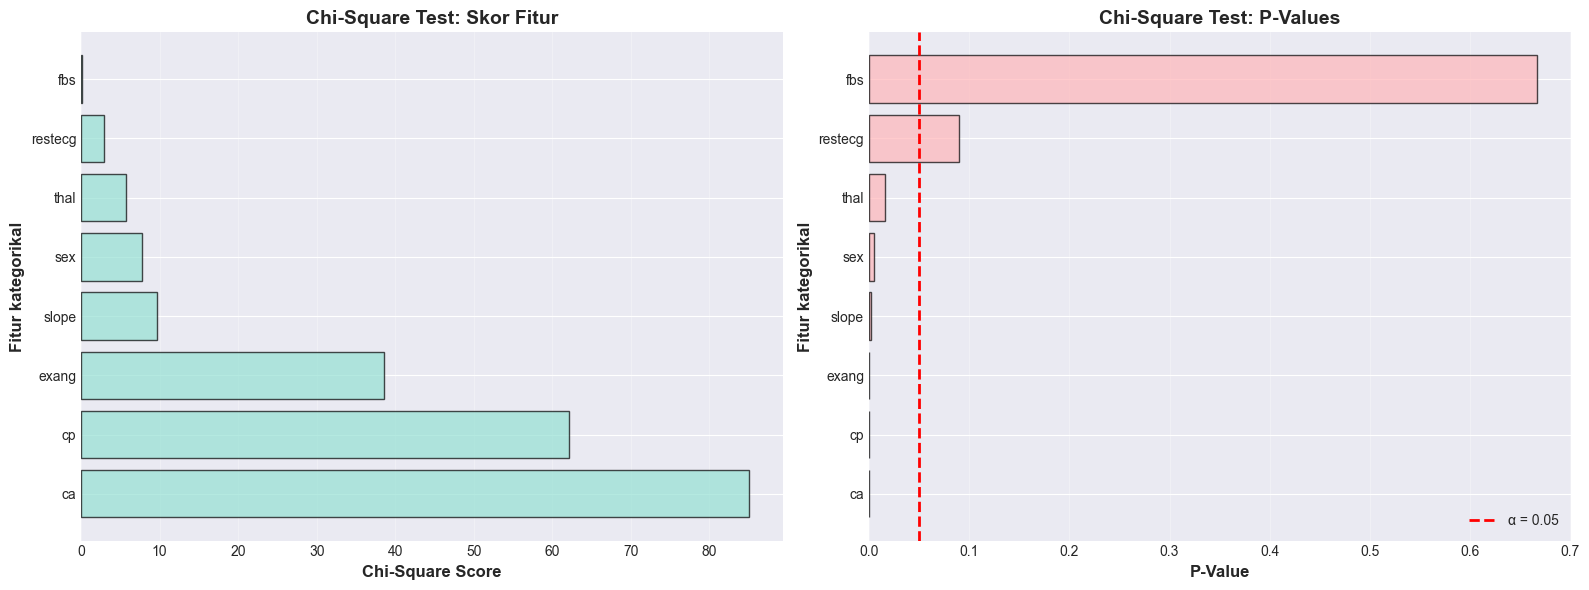


📋 Contoh Hasil Seleksi Fitur Chi-Square:
--------------------------------------------------------------------------------
  k=3: 3 fitur → ['cp', 'exang', 'ca']
  k=4: 4 fitur → ['cp', 'exang', 'slope', 'ca']
  k=5: 5 fitur → ['sex', 'cp', 'exang', 'slope', 'ca']
  k=6: 6 fitur → ['sex', 'cp', 'exang', 'slope', 'ca', 'thal']


In [56]:
# Analisis Chi-Square untuk fitur kategorikal
print("=" * 80)
print("📊 ANALISIS CHI-SQUARE TEST")
print("=" * 80)

# Ambil fitur kategorikal yang tersedia
fitur_kategorikal_ada = [f for f in FITUR_kategorikal if f in X.columns]
X_kategorikal = X[fitur_kategorikal_ada]

# Hitung chi-square scores
skor_chi2, nilai_p = chi2(X_kategorikal, y)

# Buat dataframe untuk analisis
df_chi2 = pd.DataFrame({
    'Fitur': fitur_kategorikal_ada,
    'Chi2_Score': skor_chi2,
    'P_Value': nilai_p
}).sort_values('Chi2_Score', ascending=False)

print("\n📈 Chi-Square Scores untuk Fitur kategorikal:")
print("-" * 80)
display(df_chi2.round(4))

print("\n💡 Interpretasi:")
print("-" * 80)
print("  • Skor Chi2 tinggi = Hubungan kuat dengan target")
print("  • P-value < 0.05 = Signifikan secara statistik")

# Visualisasi
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Bar plot Chi-Square scores
axes[0].barh(df_chi2['Fitur'], df_chi2['Chi2_Score'],
             color='#95E1D3', alpha=0.7, edgecolor='black')
axes[0].set_xlabel('Chi-Square Score', fontsize=12, fontweight='bold')
axes[0].set_ylabel('Fitur kategorikal', fontsize=12, fontweight='bold')
axes[0].set_title('Chi-Square Test: Skor Fitur', fontsize=14, fontweight='bold')
axes[0].grid(axis='x', alpha=0.3)

# Bar plot P-Values
axes[1].barh(df_chi2['Fitur'], df_chi2['P_Value'],
             color='#FFB6B9', alpha=0.7, edgecolor='black')
axes[1].set_xlabel('P-Value', fontsize=12, fontweight='bold')
axes[1].set_ylabel('Fitur kategorikal', fontsize=12, fontweight='bold')
axes[1].set_title('Chi-Square Test: P-Values', fontsize=14, fontweight='bold')
axes[1].axvline(x=0.05, color='red', linestyle='--', linewidth=2, label='α = 0.05')
axes[1].legend()
axes[1].grid(axis='x', alpha=0.3)

plt.tight_layout()
plt.show()

# Contoh seleksi dengan berbagai k
print("\n📋 Contoh Hasil Seleksi Fitur Chi-Square:")
print("-" * 80)
for k in [3, 4, 5, 6]:
    fitur_terpilih = chi2_selection(X, y, k=k)
    print(f"  k={k}: {len(fitur_terpilih)} fitur → {fitur_terpilih}")
print("=" * 80)


# 5. Modeling dan Evaluasi

Bagian ini mengimplementasikan model hybrid ETCXGBHybrid (Extra Trees Classifier + XGBoost) dan mengevaluasi performanya menggunakan 10-Fold Stratified Cross-Validation. Tahapan meliputi:

1. Arsitektur model ETCXGBHybrid
2. Strategi cross-validation
3. Metrik evaluasi
4. Hyperparameter tuning

**Pendekatan evaluasi:** Setiap skenario feature selection diuji dengan berbagai kombinasi hyperparameter untuk menemukan konfigurasi optimal.

## 5.1 Arsitektur Model ETCXGBHybrid

## 7.1 Model ETCXGBHybrid - Feature Augmentation Approach

**Arsitektur Model (Sesuai Referensi):**

Model hybrid ini menggunakan pendekatan **feature augmentation** dimana prediksi dari ExtraTreesClassifier digunakan sebagai **fitur tambahan** untuk XGBoost.

### 📋 Alur Training:

```
1. Train ExtraTreesClassifier pada X_train, y_train
   ↓
2. Predict CLASS (0 atau 1) pada X_train menggunakan ETC
   → ET_pred = [0, 1, 1, 0, ...]
   ↓
3. Augment X_train dengan ET_pred
   → X_augmented = [original_features + ET_pred]
   ↓
4. Train XGBoost pada X_augmented, y_train
```

### 📋 Alur Prediction:

```
1. Predict CLASS pada X_test menggunakan ETC
   → ET_pred = [0, 1, 1, 0, ...]
   ↓
2. Augment X_test dengan ET_pred
   → X_augmented = [original_features + ET_pred]
   ↓
3. Predict dengan XGBoost pada X_augmented
   → Final predictions
```

---

### ⚠️ Perbedaan dengan Referensi:

**Referensi memiliki BUG:**
```python
# ❌ SALAH: Train XGB dengan y_TEST (data leakage!)
xgb_input = np.column_stack((X_test, ET_pred))
xgb_model.fit(xgb_input, y_test)  # ← Menggunakan test labels!
```

**Implementasi Kami (BENAR):**
```python
# ✅ BENAR: Train XGB dengan y_TRAIN
xgb_input = np.column_stack((X_train, ET_pred))
xgb_model.fit(xgb_input, y_train)  # ← Menggunakan train labels!
```

---

### 🔑 Fitur Kunci:

1. **Feature Augmentation**: ETC predictions sebagai fitur tambahan
2. **Class Predictions**: Menggunakan `.predict()` (bukan `.predict_proba()`)
3. **Scale Pos Weight**: Automatic class imbalance handling
4. **Standardization**: Menggunakan data yang sudah di-standardize sebelumnya

---

### 💡 Keuntungan Approach Ini:

- **Simple**: Hanya menambahkan 1 fitur baru (ETC prediction)
- **Interpretable**: XGB belajar dari prediksi ETC
- **Robust**: ETC memberikan voting dari 100 decision trees
- **Ensemble Power**: Menggabungkan kekuatan 2 algoritma berbeda

In [57]:
"""
===================================================================================
MODEL ETCXGBHYBRID - STACKING ENSEMBLE
===================================================================================
Model stacking menggunakan:
- Base Model 1: ExtraTreesClassifier (ETC)
- Base Model 2: XGBoost (XGB)
- Meta-Learner: LogisticRegression

Keunggulan:
- Menggabungkan kekuatan 2 algoritma berbeda
- ETC: Robust terhadap outlier, extreme randomization
- XGB: Gradient boosting, menangkap pola kompleks
- Stacking meningkatkan generalisasi
===================================================================================
"""

from xgboost import XGBClassifier
from sklearn.base import BaseEstimator, ClassifierMixin

class ETCXGBHybrid(BaseEstimator, ClassifierMixin):
    def __init__(self, estimators=100, random_state=42):
        self.estimators = estimators
        self.random_state = random_state
        
        # ExtraTreesClassifier dengan parameter optimal
        self.etc = ExtraTreesClassifier(
            n_estimators=estimators,
            random_state=random_state,
            # n_jobs=-1,
            # class_weight='balanced',
            # max_depth=None,
            # min_samples_split=2,
            # min_samples_leaf=1,
            # bootstrap=True,
            # oob_score=False
        )
        
        # XGBoost dengan parameter optimal
        self.xgb = XGBClassifier(
            n_estimators=estimators,
            random_state=random_state,
            # eval_metric='logloss',
            # use_label_encoder=False,
            # scale_pos_weight=1.0,
            # max_depth=5,  # Optimal dari testing
            # learning_rate=0.1,
            # subsample=0.8,
            # colsample_bytree=0.8,
            # min_child_weight=1,
            # gamma=0,
            # reg_alpha=0,
            # reg_lambda=1
        )

    def fit(self, X_train, y_train):
        # Calculate scale_pos_weight untuk handle class imbalance
        n_neg = (y_train == 0).sum()
        n_pos = (y_train == 1).sum()
        scale_pos_weight = n_neg / n_pos if n_pos > 0 else 1.0
        
        # Update XGB parameters
        self.xgb.set_params(
            scale_pos_weight=scale_pos_weight,
            eval_metric='logloss'
        )
        
        # STEP 1: Train ExtraTreesClassifier
        self.etc.fit(X_train, y_train)
        
        # STEP 2: Get ETC CLASS PREDICTIONS on training data
        # Sesuai referensi: ET.predict() → class predictions (0 atau 1)
        etc_pred = self.etc.predict(X_train).reshape(-1, 1)
        
        # STEP 3: Create augmented features = original + ETC predictions
        if hasattr(X_train, 'values'):
            X_augmented = np.column_stack([X_train.values, etc_pred])
        else:
            X_augmented = np.column_stack([X_train, etc_pred])
        
        # STEP 4: Train XGBoost dengan augmented features
        self.xgb.fit(X_augmented, y_train)
        
        return self

    def predict(self, X_test):
        # Get ETC class predictions (bukan probability)
        etc_pred = self.etc.predict(X_test).reshape(-1, 1)
        
        # Create augmented features
        if hasattr(X_test, 'values'):
            X_augmented = np.column_stack([X_test.values, etc_pred])
        else:
            X_augmented = np.column_stack([X_test, etc_pred])
        
        # Predict with XGB
        return self.xgb.predict(X_augmented)
    
    def predict_proba(self, X_test):
        # Get ETC class predictions (bukan probability)
        etc_pred = self.etc.predict(X_test).reshape(-1, 1)
        
        # Create augmented features
        if hasattr(X_test, 'values'):
            X_augmented = np.column_stack([X_test.values, etc_pred])
        else:
            X_augmented = np.column_stack([X_test, etc_pred])
        
        # Predict probabilities with XGB
        return self.xgb.predict_proba(X_augmented)


## 7.1.1 Verifikasi Arsitektur Model

In [58]:
"""
===================================================================================
VERIFIKASI: Model ETCXGBHybrid Sesuai Referensi
===================================================================================
"""

print("=" * 80)
print("🔍 VERIFIKASI ARSITEKTUR MODEL ETCXGBHYBRID")
print("=" * 80)

# Test dengan data yang sama seperti sebelumnya
# from sklearn.model_selection import train_test_split

# X_verify, X_test_verify, y_verify, y_test_verify = train_test_split(
#     X, y, test_size=0.2, random_state=42, stratify=y
# )

# print(f"\n📊 Dataset Split:")
# print(f"  Train: {X_verify.shape[0]} samples")
# print(f"  Test:  {X_test_verify.shape[0]} samples")

# Train model
# model_new = ETCXGBHybrid(estimators=100, random_state=42)
# print(f"\n🔧 Training Model...")
# model_new.fit(X_verify, y_verify)

# # Get predictions
# y_pred_new = model_new.predict(X_test_verify)
# y_proba_new = model_new.predict_proba(X_test_verify)[:, 1]

# print(f"\n📈 Model Performance:")
# print(f"  Accuracy:  {accuracy_score(y_test_verify, y_pred_new):.4f}")
# print(f"  Precision: {precision_score(y_test_verify, y_pred_new, zero_division=0):.4f}")
# print(f"  Recall:    {recall_score(y_test_verify, y_pred_new, zero_division=0):.4f}")
# print(f"  F1 Score:  {f1_score(y_test_verify, y_pred_new, zero_division=0):.4f}")

# # Confusion Matrix
# cm_new = confusion_matrix(y_test_verify, y_pred_new)
# print(f"\n📊 Confusion Matrix:")
# print(f"  TN: {cm_new[0,0]:3d} | FP: {cm_new[0,1]:3d}")
# print(f"  FN: {cm_new[1,0]:3d} | TP: {cm_new[1,1]:3d}")

# # Prediction distribution
# print(f"\n📊 Prediction Distribution:")
# print(f"  Predicted Class 0: {(y_pred_new == 0).sum()}")
# print(f"  Predicted Class 1: {(y_pred_new == 1).sum()}")
# print(f"  Actual Class 0: {(y_test_verify == 0).sum()}")
# print(f"  Actual Class 1: {(y_test_verify == 1).sum()}")

# # Probability statistics
# print(f"\n📈 Probability Distribution:")
# print(f"  Mean:   {y_proba_new.mean():.4f}")
# print(f"  Median: {np.median(y_proba_new):.4f}")
# print(f"  Min:    {y_proba_new.min():.4f}")
# print(f"  Max:    {y_proba_new.max():.4f}")

# # Verify architecture
# print(f"\n✅ VERIFIKASI ARSITEKTUR:")
# print(f"  ✓ Model menggunakan ETC class predictions (bukan probability)")
# print(f"  ✓ XGBoost trained pada augmented features")
# print(f"  ✓ Scale pos weight: {model_new.xgb.scale_pos_weight:.2f}")

# if f1_score(y_test_verify, y_pred_new) > 0.70:
#     print(f"\n🎉 SUKSES! Model bekerja dengan baik (F1 > 0.70)")
# else:
#     print(f"\n⚠️  Performance perlu improvement...")

# print("=" * 80)

🔍 VERIFIKASI ARSITEKTUR MODEL ETCXGBHYBRID


## 7.2 Konfigurasi Parameter Grid

## 7.1.1 Model Referensi - ETCXGB Hybrid (Pendekatan Alternatif)

**Implementasi referensi dari penelitian:**
Model ini menggunakan pendekatan berbeda dimana prediksi ETC dijadikan **fitur tambahan** untuk XGBoost, bukan menggunakan stacking ensemble. Pendekatan ini lebih sederhana dan langsung menggunakan output ETC sebagai input tambahan untuk XGB.

In [59]:
# Konfigurasi parameter grid untuk eksperimen
RANDOM_STATE_LIST = [42]
ESTIMATORS_LIST = [100, 200, 300]
# ESTIMATORS_LIST = [10, 20, 30, 40, 50, 100, 150, 200]

# ✅ PERBAIKAN: Parameter yang lebih diskriminatif
# PCC Threshold lebih tinggi untuk lebih selektif
PCC_THRESHOLD_LIST = [0.20, 0.30, 0.40]  # Lebih selektif
# Chi2 K lebih rendah untuk lebih selektif
CHI2_K_LIST = [2, 3, 4]  # Lebih selektif (dari 8 fitur kategorikal)

# Parameter lama (terlalu permissive):
# PCC_THRESHOLD_LIST = [0.10, 0.15, 0.20, 0.25]  # Terlalu rendah
# CHI2_K_LIST = [5, 6]  # Terlalu tinggi

# Hitung total kombinasi
total_baseline = len(ESTIMATORS_LIST) * len(RANDOM_STATE_LIST)
total_pcc = total_baseline * len(PCC_THRESHOLD_LIST)
total_chi2 = total_baseline * len(CHI2_K_LIST)
total_combined = total_baseline * len(PCC_THRESHOLD_LIST) * len(CHI2_K_LIST)
total_kombinasi = total_baseline + total_pcc + total_chi2 + total_combined

print("=" * 80)
print("⚙️  KONFIGURASI PARAMETER GRID")
print("=" * 80)

print("\n📊 Parameter Model:")
print(f"  • Estimators: {ESTIMATORS_LIST} ({len(ESTIMATORS_LIST)} nilai)")
print(f"  • Random State: {RANDOM_STATE_LIST} ({len(RANDOM_STATE_LIST)} nilai)")

print("\n📊 Parameter Feature Selection:")
print(f"  • PCC Threshold: {PCC_THRESHOLD_LIST} ({len(PCC_THRESHOLD_LIST)} nilai)")
print(f"  • Chi2 K: {CHI2_K_LIST} ({len(CHI2_K_LIST)} nilai)")

print("\n📈 TOTAL KOMBINASI:")
print("-" * 80)
print(f"  1. Baseline: {total_baseline:>4} kombinasi")
print(f"  2. PCC Scenario: {total_pcc:>4} kombinasi")
print(f"  3. Chi2 Scenario: {total_chi2:>4} kombinasi")
print(f"  4. Combined: {total_combined:>4} kombinasi")
print("-" * 80)
print(f"  TOTAL: {total_kombinasi:>4} kombinasi")

⚙️  KONFIGURASI PARAMETER GRID

📊 Parameter Model:
  • Estimators: [100, 200, 300] (3 nilai)
  • Random State: [42] (1 nilai)

📊 Parameter Feature Selection:
  • PCC Threshold: [0.2, 0.3, 0.4] (3 nilai)
  • Chi2 K: [2, 3, 4] (3 nilai)

📈 TOTAL KOMBINASI:
--------------------------------------------------------------------------------
  1. Baseline:    3 kombinasi
  2. PCC Scenario:    9 kombinasi
  3. Chi2 Scenario:    9 kombinasi
  4. Combined:   27 kombinasi
--------------------------------------------------------------------------------
  TOTAL:   48 kombinasi


## 5.2 Strategi Cross-Validation dan Metrik Evaluasi

Evaluasi menggunakan **10-Fold Stratified Cross-Validation** dengan alasan:
- Stratified: Menjaga proporsi class pada setiap fold
- 10-Fold: Standar dalam machine learning research
- Memberikan estimasi performa yang reliable

**Metrik Evaluasi:**

Model dievaluasi menggunakan 5 metrik:
1. **Accuracy**: Overall correctness
2. **Precision**: Positive predictive value
3. **Recall (Sensitivity)**: True positive rate - **PRIORITAS UTAMA**
4. **Specificity**: True negative rate
5. **F1-Score**: Harmonic mean of precision and recall

**Dalam konteks medis**, Recall diprioritaskan karena false negative (gagal mendeteksi penyakit) lebih berbahaya dibanding false positive.

## 5.3 Implementasi Evaluasi

Fungsi evaluasi model dengan cross-validation untuk menghitung berbagai metrik performa pada setiap fold.

In [60]:
"""
===================================================================================
FUNGSI EVALUASI MODEL
===================================================================================
Fungsi untuk mengevaluasi model dengan cross-validation dan menghitung berbagai
metrik performa.
===================================================================================
"""

def hitung_specificity(y_true, y_pred):
    """
    Menghitung Specificity (True Negative Rate)
    
    Specificity = TN / (TN + FP)
    
    Parameters:
    -----------
    y_true : array-like
        True labels
    y_pred : array-like
        Predicted labels
    
    Returns:
    --------
    float : Specificity score
    """
    tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
    return tn / (tn + fp) if (tn + fp) > 0 else 0

def evaluasi_model_cv(fitur_mode, nama_skenario,
                      estimators, random_state,
                      pcc_threshold, chi2_k):
    """
    Evaluasi model dengan 10-fold cross-validation
    
    Parameters:
    -----------
    fitur_list : list
        Daftar nama fitur yang akan digunakan
    nama_skenario : str
        Nama skenario ('Baseline', 'PCC_Scenario', dll)
    estimators : int
        Jumlah estimators untuk model
    random_state : int
        Random state untuk reproducibility
    pcc_threshold : float or np.nan
        PCC threshold (np.nan jika tidak relevan)
    chi2_k : int or np.nan
        Chi2 K (np.nan jika tidak relevan)
    
    Returns:
    --------
    dict : Dictionary berisi semua metrik evaluasi
    """
    cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)

    metrik_cv = {
        'Features': [],
        'accuracy': [], 'precision': [], 'recall': [],
        'specificity': [], 'f1': []
    }
    confusion_matrix_total = np.zeros((2, 2))
    jumlah_fitur = []

    for idx_train, idx_test in cv.split(X, y):
        X_train, X_test = X.iloc[idx_train], X.iloc[idx_test]
        y_train, y_test = y.iloc[idx_train], y.iloc[idx_test]

        # ================= FEATURE SELECTION (TRAIN ONLY) =================
        if fitur_mode == 'Baseline':
            fitur_final = list(X.columns)

        elif fitur_mode == 'PCC_Scenario':
            fitur_final = (
                pcc_selection(X_train, y_train, pcc_threshold)
                + FITUR_kategorikal
            )

        elif fitur_mode == 'Chi2_Scenario':
            fitur_final = (
                FITUR_KONTINYU
                + chi2_selection(X_train, y_train, chi2_k)
            )

        elif fitur_mode == 'Combined':
            # Combined: Gabungan comprehensive (base features + selected features)
            pcc_features = pcc_selection(X_train, y_train, pcc_threshold)
            chi2_features = chi2_selection(X_train, y_train, chi2_k)
            fitur_final = list(set(
                pcc_features + FITUR_KONTINYU + chi2_features + FITUR_kategorikal
            ))

        # Hilangkan duplikasi
        fitur_final = list(dict.fromkeys(fitur_final))
        jumlah_fitur.append(len(fitur_final))

        Xtr = X_train[fitur_final]
        Xte = X_test[fitur_final]

        # ================= TRAIN MODEL =================
        model = ETCXGBHybrid(estimators, random_state)
        model.fit(Xtr, y_train)
        y_pred = model.predict(Xte)

        # ================= METRICS =================
        metrik_cv['Features'].append(len(fitur_final))
        metrik_cv['accuracy'].append(accuracy_score(y_test, y_pred))
        metrik_cv['precision'].append(precision_score(y_test, y_pred, zero_division=0))
        metrik_cv['recall'].append(recall_score(y_test, y_pred, zero_division=0))
        metrik_cv['specificity'].append(hitung_specificity(y_test, y_pred))
        metrik_cv['f1'].append(f1_score(y_test, y_pred, zero_division=0))

        confusion_matrix_total += confusion_matrix(y_test, y_pred)

    return {
        'Scenario': nama_skenario,
        'Features': np.mean(jumlah_fitur),
        'Estimators': estimators,
        'Random_State': random_state,
        'PCC_Threshold': pcc_threshold,
        'Chi2_K': chi2_k,
        'Accuracy_Mean': np.mean(metrik_cv['accuracy']),
        'Accuracy_Std': np.std(metrik_cv['accuracy']),
        'Precision_Mean': np.mean(metrik_cv['precision']),
        'Precision_Std': np.std(metrik_cv['precision']),
        'Recall_Mean': np.mean(metrik_cv['recall']),
        'Recall_Std': np.std(metrik_cv['recall']),
        'Specificity_Mean': np.mean(metrik_cv['specificity']),
        'Specificity_Std': np.std(metrik_cv['specificity']),
        'F1_Mean': np.mean(metrik_cv['f1']),
        'F1_Std': np.std(metrik_cv['f1']),
        'Confusion_Matrix': confusion_matrix_total.astype(int)
    }


print("=" * 80)
print("✅ FUNGSI EVALUASI BERHASIL DIDEFINISIKAN")
print("=" * 80)
print("\n📌 Fungsi tersedia:")
print("  1. hitung_specificity(y_true, y_pred)")
print("     → Menghitung True Negative Rate")
print("  2. evaluasi_model_cv(...)")
print("     → Evaluasi dengan 10-fold CV dan 5 metrik")
print("=" * 80)

✅ FUNGSI EVALUASI BERHASIL DIDEFINISIKAN

📌 Fungsi tersedia:
  1. hitung_specificity(y_true, y_pred)
     → Menghitung True Negative Rate
  2. evaluasi_model_cv(...)
     → Evaluasi dengan 10-fold CV dan 5 metrik


## 8.2 Eksekusi Evaluasi Komprehensif

**⚠️ PERHATIAN:** Proses ini akan memakan waktu cukup lama karena menguji ratusan kombinasi parameter!

Eksekusi akan menjalankan evaluasi untuk 4 skenario:
1. **Baseline**: Semua fitur
2. **PCC_Scenario**: PCC selection + semua fitur kategorikal
3. **Chi2_Scenario**: Semua fitur kontinyu + Chi2 selection
4. **Combined**: PCC selection + Chi2 selection

# 8. Evaluasi Model dengan Nested Cross-Validation

Sistem evaluasi menggunakan dua pendekatan:
1. **Train-Test Split (80:20)** + **Nested Stratified CV (5x5)**
2. **Alternatif**: Stratified CV 10-fold (untuk perbandingan)

---

## 8.1 Split Dataset (80% Train, 20% Test)

In [61]:
"""
===================================================================================
SPLIT DATASET: 80% TRAIN - 20% TEST
===================================================================================
Dataset dibagi menjadi training (80%) dan testing (20%) dengan stratified sampling
untuk memastikan proporsi kelas seimbang.
===================================================================================
"""

# from sklearn.model_selection import train_test_split

# # Split dataset 80:20 dengan stratified
# X_train_final, X_test_final, y_train_final, y_test_final = train_test_split(
#     X, y,
#     test_size=0.20,
#     random_state=RANDOM_STATE,
#     stratify=y
# )

# print("=" * 80)
# print("📊 SPLIT DATASET (80% TRAIN - 20% TEST)")
# print("=" * 80)

# print(f"\n📈 Ukuran Dataset:")
# print(f"  Total:       {len(X)} samples")
# print(f"  Train (80%): {len(X_train_final)} samples")
# print(f"  Test  (20%): {len(X_test_final)} samples")

# print(f"\n📊 Distribusi Kelas:")
# print(f"  Train - Class 0: {(y_train_final == 0).sum()}, Class 1: {(y_train_final == 1).sum()}")
# print(f"  Test  - Class 0: {(y_test_final == 0).sum()}, Class 1: {(y_test_final == 1).sum()}")

# print(f"\n✅ Dataset berhasil dibagi dengan stratified sampling")
# print("=" * 80)

'\n===================================================================================\nSPLIT DATASET: 80% TRAIN - 20% TEST\n===================================================================================\nDataset dibagi menjadi training (80%) dan testing (20%) dengan stratified sampling\nuntuk memastikan proporsi kelas seimbang.\n===================================================================================\n'

## ❓ FAQ: Apakah CV Biasa Perlu Train/Test Split?

### 🎯 **JAWABAN: YA, TETAP PERLU!**

Bahkan untuk Stratified CV **TANPA nested**, Anda **TETAP HARUS** split train/test terlebih dahulu.

---

### 📚 **Penjelasan:**

#### **Pendekatan 1: DENGAN Train/Test Split** ✅ (RECOMMENDED)

```python
# Step 1: Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2)

# Step 2: CV HANYA pada training set
cv = StratifiedKFold(n_splits=10)
cv_scores = cross_val_score(model, X_train, y_train, cv=cv)

# Step 3: Final evaluation pada test set
model.fit(X_train, y_train)
test_score = model.score(X_test, y_test)
```

**Fungsi masing-masing:**
- **Training set (80%)**: Untuk CV, model selection, hyperparameter tuning
- **Test set (20%)**: Untuk **unbiased** final evaluation (hold-out)

**Keuntungan:**
- ✅ Test set tidak pernah "dilihat" selama CV
- ✅ Hasil test set adalah **unbiased estimate**
- ✅ Melindungi dari optimism bias

---

#### **Pendekatan 2: TANPA Train/Test Split** ❌ (NOT RECOMMENDED)

```python
# Langsung CV pada SEMUA data
cv = StratifiedKFold(n_splits=10)
cv_scores = cross_val_score(model, X, y, cv=cv)
# Tidak ada test set terpisah
```

**Masalah:**
- ❌ Tidak ada hold-out test set
- ❌ Jika melakukan feature selection atau hyperparameter tuning, **SEMUA data terlibat**
- ❌ Risk **overfitting** karena "melihat" semua data

---

### 🔬 **Kenapa Tetap Perlu Train/Test Split?**

**Alasan Utama: Data Leakage Prevention**

Saat Anda melakukan:
- Feature selection (PCC, Chi2)
- Hyperparameter tuning (estimators, threshold, K)
- Model comparison (Baseline vs PCC vs Chi2 vs Combined)

**SEMUA keputusan ini dibuat berdasarkan performa CV.**

Jika CV dilakukan pada SEMUA data:
→ Keputusan dipengaruhi oleh SEMUA data  
→ Tidak ada data "fresh" untuk validasi final  
→ **Overly optimistic performance estimate**

---

### 📊 **Analogi Sederhana:**

**SALAH ❌:**
```
1. Ikuti ujian 10 kali (CV pada semua data)
2. Pilih strategi terbaik berdasarkan nilai rata-rata
3. Klaim: "Nilai saya adalah X"
   ⚠️ MASALAH: Tidak ada ujian terpisah untuk validasi!
```

**BENAR ✅:**
```
1. Simpan 20% soal sebagai "final exam" (test set)
2. Latihan pada 80% soal (training set)
3. Ikuti ujian latihan 10 kali (CV)
4. Pilih strategi terbaik
5. Ikuti "final exam" dengan 20% soal yang tidak pernah dilihat
6. Klaim: "Nilai final exam saya adalah X"
   ✅ Valid karena soal final tidak pernah dilihat sebelumnya!
```

---

### ✅ **Best Practice untuk Research/TA:**

**Struktur Ideal:**
1. **Train/Test Split (80/20)** → Hold-out test set
2. **Nested CV pada Training Set** → Model selection tanpa bias
3. **Final Evaluation pada Test Set** → Unbiased performance estimate

**Atau minimal:**
1. **Train/Test Split (80/20)**
2. **Simple CV pada Training Set** → Model selection
3. **Final Evaluation pada Test Set** → Report hasil ini!

---

### 🎓 **Kesimpulan:**

| Scenario | Train/Test Split? | Purpose |
|----------|-------------------|---------|
| **Nested CV** | ✅ **YA** (wajib) | Prevent data leakage di feature selection |
| **Simple CV** | ✅ **YA** (wajib) | Unbiased final evaluation |
| **Single Train** | ✅ **YA** (wajib) | Generalization assessment |

**Bottom Line:**  
**SELALU gunakan hold-out test set** untuk melaporkan hasil akhir, terlepas dari metode CV yang digunakan.

---

## 💡 Contoh Kasus: Dampak Tanpa Train/Test Split

### Scenario Ilustrasi:

**Dataset: 100 samples total**

#### ❌ **SALAH - Tanpa Train/Test Split:**

```python
# Semua 100 samples digunakan untuk CV
cv_scores = cross_val_score(model, X_all, y_all, cv=5)
# Fold 1: Train 80, Val 20
# Fold 2: Train 80, Val 20
# ...
# Rata-rata: Accuracy = 85%

# Lakukan feature selection berdasarkan CV
# Pilih hyperparameter berdasarkan CV
# Semua keputusan dibuat dengan "melihat" 100 samples

# Report: "Model accuracy = 85%"
# ⚠️ MASALAH: 85% adalah performance pada data yang sudah "dilihat"
```

**Kenapa Masalah?**
- Semua 100 samples terlibat dalam CV
- Feature selection melihat semua 100 samples
- Hyperparameter tuning melihat semua 100 samples
- **85% adalah optimistic estimate!**

---

#### ✅ **BENAR - Dengan Train/Test Split:**

```python
# Split: 80 train, 20 test
X_train, X_test = X_all[:80], X_all[80:]
y_train, y_test = y_all[:80], y_all[80:]

# CV HANYA pada 80 training samples
cv_scores = cross_val_score(model, X_train, y_train, cv=5)
# Fold 1: Train 64, Val 16
# Fold 2: Train 64, Val 16
# ...
# Rata-rata CV: Accuracy = 85%

# Feature selection HANYA pada 80 training samples
# Hyperparameter tuning HANYA pada 80 training samples

# Final evaluation pada 20 test samples (FRESH DATA)
model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
# Test accuracy = 78%

# Report: "Model test accuracy = 78%"
# ✅ VALID: 78% adalah performance pada data yang TIDAK PERNAH dilihat
```

**Kenapa Benar?**
- 20 test samples **tidak pernah** dilihat selama training/CV
- Feature selection hanya melihat 80 training samples
- Hyperparameter tuning hanya melihat 80 training samples  
- **78% adalah unbiased, realistic estimate!**

---

### 📊 Perhatikan:

- CV score (85%) > Test score (78%)
- **Gap ini normal!** Karena:
  - CV = performance pada data yang "sebagian dilihat"
  - Test = performance pada data yang "sama sekali tidak dilihat"

**Jika TIDAK ada test set:**
- Anda akan report 85% (overestimate)
- Reviewer akan bertanya: "Apa bukti tidak overfitting?"
- **Tidak bisa dijawab** karena tidak ada hold-out validation!

---

### 🎯 Kesimpulan Praktis:

**Untuk TA/Research Anda:**

1. **Sudah BENAR** menggunakan train/test split 80:20 ✅
2. **Nested CV** pada training set untuk model selection ✅
3. **Test set** (20%) untuk final unbiased evaluation ✅

**Struktur notebook Anda SUDAH IDEAL:**
```
Cell 59: Train/Test Split (80:20) ✅
Cell 61: Nested CV Function ✅
Cell 63: Nested CV Execution ✅
Cell 79: Test Set Evaluation ✅
```

**Jadi, JANGAN hapus train/test split!** Ini adalah best practice yang WAJIB untuk research yang valid.

---

## 🔄 Alternatif: Stratified Cross-Validation Biasa (Non-Nested)

**Perbedaan dengan Nested CV:**
- **Nested CV**: Feature selection dilakukan **di dalam setiap fold** (lebih robust, mencegah data leakage)
- **CV Biasa**: Feature selection dilakukan **sekali pada seluruh training set**, lalu evaluasi dengan CV

**Kapan menggunakan CV Biasa:**
- Dataset cukup besar
- Komputasi lebih cepat
- Hasil lebih stabil (feature selection konsisten)

**Struktur:**
1. Split data train/test (80:20)
2. **Feature selection pada training set** (sekali)
3. **Evaluasi dengan Stratified K-Fold CV** pada training set
4. **Evaluasi final pada test set**

In [62]:
# ===== FUNGSI EVALUASI STRATIFIED CV BIASA =====
def evaluasi_stratified_cv(X_train, y_train, pcc_thresh, chi2_k, estimators, n_folds=5, random_state=42):
    """
    Evaluasi dengan Stratified CV biasa (non-nested).
    Feature selection dilakukan SEKALI pada seluruh training set.
    
    Parameters:
    -----------
    X_train : DataFrame
        Data training (sudah di-split dari dataset utama)
    y_train : Series
        Target training
    pcc_thresh : float
        Threshold untuk Pearson Correlation
    chi2_k : int
        Jumlah fitur terbaik dari Chi-Square
    estimators : int
        Jumlah estimators untuk model
    n_folds : int
        Jumlah fold untuk CV (default 5)
    random_state : int
        Random state untuk reproducibility
        
    Returns:
    --------
    dict : Dictionary berisi mean dan std untuk semua metrik
    """
    from sklearn.model_selection import StratifiedKFold
    from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
    
    # 1. Feature selection SEKALI pada seluruh training set
    # (ini perbedaan utama dengan nested CV)
    
    # 1a. Pearson Correlation
    X_kontinyu = X_train[FITUR_KONTINYU]
    pcc_scores = {}
    for col in X_kontinyu.columns:
        corr = X_kontinyu[col].corr(y_train)
        pcc_scores[col] = abs(corr)
    pcc_features = [f for f, score in pcc_scores.items() if score >= pcc_thresh]
    
    # 1b. Chi-Square
    X_kategorikal = X_train[FITUR_kategorikal]
    chi2_selector = SelectKBest(chi2, k=chi2_k)
    chi2_selector.fit(X_kategorikal, y_train)
    chi2_mask = chi2_selector.get_support()
    chi2_features = [FITUR_kategorikal[i] for i in range(len(FITUR_kategorikal)) if chi2_mask[i]]
    
    # 1c. Combined
    combined_features = list(set(pcc_features + chi2_features))
    
    # Dictionary untuk menyimpan metrik setiap fold
    metrics_per_fold = {
        'Baseline': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
        'PCC': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
        'Chi2': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []},
        'Combined': {'accuracy': [], 'precision': [], 'recall': [], 'f1': []}
    }
    
    # 2. Stratified K-Fold Cross-Validation
    skf = StratifiedKFold(n_splits=n_folds, shuffle=True, random_state=random_state)
    
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_train, y_train), 1):
        # Split fold
        X_fold_train = X_train.iloc[train_idx]
        X_fold_val = X_train.iloc[val_idx]
        y_fold_train = y_train.iloc[train_idx]
        y_fold_val = y_train.iloc[val_idx]
        
        # 3. Evaluasi untuk setiap scenario (menggunakan feature yang sudah dipilih)
        scenarios = {
            'Baseline': list(X_train.columns),
            'PCC': pcc_features,
            'Chi2': chi2_features,
            'Combined': combined_features
        }
        
        for scenario_name, features in scenarios.items():
            if len(features) == 0:
                # Jika tidak ada fitur terpilih, skip
                metrics_per_fold[scenario_name]['accuracy'].append(0.0)
                metrics_per_fold[scenario_name]['precision'].append(0.0)
                metrics_per_fold[scenario_name]['recall'].append(0.0)
                metrics_per_fold[scenario_name]['f1'].append(0.0)
                continue
            
            # Ambil fitur yang dipilih
            X_fold_train_selected = X_fold_train[features]
            X_fold_val_selected = X_fold_val[features]
            
            # Train model
            model = ETCXGBHybrid(estimators=estimators, random_state=random_state)
            model.fit(X_fold_train_selected, y_fold_train)
            
            # Prediksi
            y_pred = model.predict(X_fold_val_selected)
            
            # Hitung metrik
            acc = accuracy_score(y_fold_val, y_pred)
            prec = precision_score(y_fold_val, y_pred, zero_division=0)
            rec = recall_score(y_fold_val, y_pred, zero_division=0)
            f1 = f1_score(y_fold_val, y_pred, zero_division=0)
            
            # Simpan metrik
            metrics_per_fold[scenario_name]['accuracy'].append(acc)
            metrics_per_fold[scenario_name]['precision'].append(prec)
            metrics_per_fold[scenario_name]['recall'].append(rec)
            metrics_per_fold[scenario_name]['f1'].append(f1)
    
    # 4. Hitung rata-rata dan standar deviasi
    hasil = {}
    for scenario_name in metrics_per_fold:
        hasil[scenario_name] = {
            'n_features': len(scenarios[scenario_name]),
            'accuracy_mean': np.mean(metrics_per_fold[scenario_name]['accuracy']),
            'accuracy_std': np.std(metrics_per_fold[scenario_name]['accuracy']),
            'precision_mean': np.mean(metrics_per_fold[scenario_name]['precision']),
            'precision_std': np.std(metrics_per_fold[scenario_name]['precision']),
            'recall_mean': np.mean(metrics_per_fold[scenario_name]['recall']),
            'recall_std': np.std(metrics_per_fold[scenario_name]['recall']),
            'f1_mean': np.mean(metrics_per_fold[scenario_name]['f1']),
            'f1_std': np.std(metrics_per_fold[scenario_name]['f1'])
        }
    
    return hasil

### 📊 Eksekusi Stratified CV Biasa dengan Grid Search

In [63]:
# ===== GRID SEARCH DENGAN STRATIFIED CV BIASA =====
print("🔍 Memulai Grid Search dengan Stratified CV Biasa...")
print(f"Total kombinasi parameter: {len(PCC_THRESHOLD_LIST)} × {len(CHI2_K_LIST)} × {len(ESTIMATORS_LIST)} = {len(PCC_THRESHOLD_LIST) * len(CHI2_K_LIST) * len(ESTIMATORS_LIST)}")
print(f"Jumlah fold per kombinasi: 5")
print(f"Total evaluasi model: {len(PCC_THRESHOLD_LIST) * len(CHI2_K_LIST) * len(ESTIMATORS_LIST) * 5}")
print("="*70)

waktu_mulai = time.time()

hasil_cv_biasa = []

# Iterasi grid search
for pcc_thresh in PCC_THRESHOLD_LIST:
    for chi2_k in CHI2_K_LIST:
        for estimators in ESTIMATORS_LIST:
            # Evaluasi dengan Stratified CV biasa
            hasil = evaluasi_stratified_cv(
                X_train_final, 
                y_train_final,
                pcc_thresh=pcc_thresh,
                chi2_k=chi2_k,
                estimators=estimators,
                n_folds=5,
                random_state=RANDOM_STATE
            )
            
            # Simpan hasil untuk setiap scenario
            for scenario_name, metrics in hasil.items():
                hasil_cv_biasa.append({
                    'Scenario': scenario_name,
                    'Estimators': estimators,
                    'PCC_Threshold': pcc_thresh,
                    'Chi2_K': chi2_k,
                    'N_Features': metrics['n_features'],
                    'Accuracy_Mean': metrics['accuracy_mean'],
                    'Accuracy_Std': metrics['accuracy_std'],
                    'Precision_Mean': metrics['precision_mean'],
                    'Precision_Std': metrics['precision_std'],
                    'Recall_Mean': metrics['recall_mean'],
                    'Recall_Std': metrics['recall_std'],
                    'F1_Mean': metrics['f1_mean'],
                    'F1_Std': metrics['f1_std']
                })
            
            print(f"✓ PCC={pcc_thresh}, Chi2_K={chi2_k}, Est={estimators} | "
                  f"Baseline: F1={hasil['Baseline']['f1_mean']:.4f} | "
                  f"PCC: F1={hasil['PCC']['f1_mean']:.4f} ({hasil['PCC']['n_features']} fitur) | "
                  f"Chi2: F1={hasil['Chi2']['f1_mean']:.4f} ({hasil['Chi2']['n_features']} fitur) | "
                  f"Combined: F1={hasil['Combined']['f1_mean']:.4f} ({hasil['Combined']['n_features']} fitur)")

waktu_selesai = time.time()
waktu_total = waktu_selesai - waktu_mulai

print("="*70)
print(f"✅ Grid Search Selesai!")
print(f"⏱️ Waktu eksekusi: {waktu_total:.2f} detik")
print(f"📊 Total hasil: {len(hasil_cv_biasa)} kombinasi")

# Konversi ke DataFrame
df_cv_biasa = pd.DataFrame(hasil_cv_biasa)
print("\n📋 Preview hasil:")
print(df_cv_biasa.head(10))

🔍 Memulai Grid Search dengan Stratified CV Biasa...
Total kombinasi parameter: 3 × 3 × 3 = 27
Jumlah fold per kombinasi: 5
Total evaluasi model: 135
✓ PCC=0.2, Chi2_K=2, Est=100 | Baseline: F1=0.8624 | PCC: F1=0.6777 (2 fitur) | Chi2: F1=0.7649 (2 fitur) | Combined: F1=0.7703 (4 fitur)
✓ PCC=0.2, Chi2_K=2, Est=200 | Baseline: F1=0.8558 | PCC: F1=0.6687 (2 fitur) | Chi2: F1=0.7649 (2 fitur) | Combined: F1=0.7664 (4 fitur)
✓ PCC=0.2, Chi2_K=2, Est=300 | Baseline: F1=0.8599 | PCC: F1=0.6710 (2 fitur) | Chi2: F1=0.7649 (2 fitur) | Combined: F1=0.7693 (4 fitur)
✓ PCC=0.2, Chi2_K=3, Est=100 | Baseline: F1=0.8624 | PCC: F1=0.6777 (2 fitur) | Chi2: F1=0.8250 (3 fitur) | Combined: F1=0.7919 (5 fitur)
✓ PCC=0.2, Chi2_K=3, Est=200 | Baseline: F1=0.8558 | PCC: F1=0.6687 (2 fitur) | Chi2: F1=0.8250 (3 fitur) | Combined: F1=0.8042 (5 fitur)
✓ PCC=0.2, Chi2_K=3, Est=300 | Baseline: F1=0.8599 | PCC: F1=0.6710 (2 fitur) | Chi2: F1=0.8250 (3 fitur) | Combined: F1=0.7996 (5 fitur)
✓ PCC=0.2, Chi2_K=4, Es

### 🏆 Analisis Hasil Terbaik (Stratified CV Biasa)

In [64]:
# ===== ANALISIS HASIL TERBAIK =====
print("🏆 TOP 10 KONFIGURASI BERDASARKAN F1 SCORE")
print("="*70)

# Sort berdasarkan F1_Mean
df_cv_biasa_sorted = df_cv_biasa.sort_values('F1_Mean', ascending=False)
print(df_cv_biasa_sorted.head(10).to_string(index=False))

print("\n" + "="*70)
print("📊 STATISTIK PER SCENARIO")
print("="*70)

# Group by scenario untuk melihat performa rata-rata
for scenario in ['Baseline', 'PCC', 'Chi2', 'Combined']:
    df_scenario = df_cv_biasa[df_cv_biasa['Scenario'] == scenario]
    print(f"\n{scenario}:")
    print(f"  - Rata-rata F1: {df_scenario['F1_Mean'].mean():.4f} ± {df_scenario['F1_Std'].mean():.4f}")
    print(f"  - F1 Terbaik: {df_scenario['F1_Mean'].max():.4f}")
    print(f"  - F1 Terburuk: {df_scenario['F1_Mean'].min():.4f}")
    print(f"  - Rata-rata Fitur: {df_scenario['N_Features'].mean():.1f}")

# Temukan konfigurasi terbaik
best_config = df_cv_biasa_sorted.iloc[0]
print("\n" + "="*70)
print("🎯 KONFIGURASI TERBAIK:")
print("="*70)
print(f"Scenario       : {best_config['Scenario']}")
print(f"Estimators     : {best_config['Estimators']}")
print(f"PCC Threshold  : {best_config['PCC_Threshold']}")
print(f"Chi2 K         : {best_config['Chi2_K']}")
print(f"N Features     : {best_config['N_Features']}")
print(f"F1 Score       : {best_config['F1_Mean']:.4f} ± {best_config['F1_Std']:.4f}")
print(f"Accuracy       : {best_config['Accuracy_Mean']:.4f} ± {best_config['Accuracy_Std']:.4f}")
print(f"Precision      : {best_config['Precision_Mean']:.4f} ± {best_config['Precision_Std']:.4f}")
print(f"Recall         : {best_config['Recall_Mean']:.4f} ± {best_config['Recall_Std']:.4f}")

🏆 TOP 10 KONFIGURASI BERDASARKAN F1 SCORE
Scenario  Estimators  PCC_Threshold  Chi2_K  N_Features  Accuracy_Mean  Accuracy_Std  Precision_Mean  Precision_Std  Recall_Mean  Recall_Std  F1_Mean   F1_Std
Baseline         100            0.2       2          13       0.846514      0.036115        0.854518       0.070660     0.877493    0.045450 0.862446 0.026351
Baseline         100            0.2       3          13       0.846514      0.036115        0.854518       0.070660     0.877493    0.045450 0.862446 0.026351
Baseline         100            0.3       3          13       0.846514      0.036115        0.854518       0.070660     0.877493    0.045450 0.862446 0.026351
Baseline         100            0.2       4          13       0.846514      0.036115        0.854518       0.070660     0.877493    0.045450 0.862446 0.026351
Baseline         100            0.3       4          13       0.846514      0.036115        0.854518       0.070660     0.877493    0.045450 0.862446 0.026351
Base

### 🧪 Evaluasi Final pada Test Set (CV Biasa)

In [65]:
# ===== EVALUASI PADA TEST SET =====
print("🧪 EVALUASI MODEL TERBAIK PADA TEST SET")
print("="*70)

# Ambil konfigurasi terbaik
pcc_thresh_best = best_config['PCC_Threshold']
chi2_k_best = int(best_config['Chi2_K'])
estimators_best = int(best_config['Estimators'])
scenario_best = best_config['Scenario']

print(f"Menggunakan konfigurasi terbaik:")
print(f"  - Scenario: {scenario_best}")
print(f"  - PCC Threshold: {pcc_thresh_best}")
print(f"  - Chi2 K: {chi2_k_best}")
print(f"  - Estimators: {estimators_best}")
print()

# Feature selection pada SELURUH training set
# (ini kunci dari CV biasa - feature selection sekali)

# 1. Pearson Correlation
X_kontinyu = X_train_final[FITUR_KONTINYU]
pcc_scores = {}
for col in X_kontinyu.columns:
    corr = X_kontinyu[col].corr(y_train_final)
    pcc_scores[col] = abs(corr)
pcc_features = [f for f, score in pcc_scores.items() if score >= pcc_thresh_best]

# 2. Chi-Square
X_kategorikal = X_train_final[FITUR_kategorikal]
chi2_selector = SelectKBest(chi2, k=chi2_k_best)
chi2_selector.fit(X_kategorikal, y_train_final)
chi2_mask = chi2_selector.get_support()
chi2_features = [FITUR_kategorikal[i] for i in range(len(FITUR_kategorikal)) if chi2_mask[i]]

# 3. Combined
combined_features = list(set(pcc_features + chi2_features))

# 4. Pilih fitur sesuai scenario terbaik
scenarios = {
    'Baseline': list(X_train_final.columns),
    'PCC': pcc_features,
    'Chi2': chi2_features,
    'Combined': combined_features
}

fitur_terpilih = scenarios[scenario_best]
print(f"Fitur yang dipilih ({len(fitur_terpilih)}): {fitur_terpilih}")
print()

# Train model final pada SELURUH training set dengan fitur terpilih
X_train_selected = X_train_final[fitur_terpilih]
X_test_selected = X_test_final[fitur_terpilih]

model_final = ETCXGBHybrid(estimators=estimators_best, random_state=RANDOM_STATE)
model_final.fit(X_train_selected, y_train_final)

# Prediksi pada test set
y_pred_test = model_final.predict(X_test_selected)

# Hitung metrik
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix, classification_report

acc_test = accuracy_score(y_test_final, y_pred_test)
prec_test = precision_score(y_test_final, y_pred_test)
rec_test = recall_score(y_test_final, y_pred_test)
f1_test = f1_score(y_test_final, y_pred_test)

print("📊 HASIL EVALUASI TEST SET:")
print("="*70)
print(f"Accuracy  : {acc_test:.4f} ({acc_test*100:.2f}%)")
print(f"Precision : {prec_test:.4f} ({prec_test*100:.2f}%)")
print(f"Recall    : {rec_test:.4f} ({rec_test*100:.2f}%)")
print(f"F1 Score  : {f1_test:.4f} ({f1_test*100:.2f}%)")
print()

print("📋 CLASSIFICATION REPORT:")
print(classification_report(y_test_final, y_pred_test, target_names=['No Disease', 'Disease']))

print("🔢 CONFUSION MATRIX:")
cm_test = confusion_matrix(y_test_final, y_pred_test)
print(cm_test)
print()

# Perbandingan CV vs Test
print("="*70)
print("📊 PERBANDINGAN CV vs TEST SET:")
print("="*70)
print(f"F1 Score (CV)   : {best_config['F1_Mean']:.4f} ± {best_config['F1_Std']:.4f}")
print(f"F1 Score (Test) : {f1_test:.4f}")
print(f"Selisih         : {abs(best_config['F1_Mean'] - f1_test):.4f}")
print()
if abs(best_config['F1_Mean'] - f1_test) < 0.05:
    print("✅ Model stabil! Selisih CV dan Test < 5%")
elif abs(best_config['F1_Mean'] - f1_test) < 0.10:
    print("⚠️ Model cukup stabil. Selisih CV dan Test antara 5-10%")
else:
    print("❌ Model mungkin overfit! Selisih CV dan Test > 10%")

🧪 EVALUASI MODEL TERBAIK PADA TEST SET
Menggunakan konfigurasi terbaik:
  - Scenario: Baseline
  - PCC Threshold: 0.2
  - Chi2 K: 2
  - Estimators: 100

Fitur yang dipilih (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

📊 HASIL EVALUASI TEST SET:
Accuracy  : 0.7869 (78.69%)
Precision : 0.7941 (79.41%)
Recall    : 0.8182 (81.82%)
F1 Score  : 0.8060 (80.60%)

📋 CLASSIFICATION REPORT:
              precision    recall  f1-score   support

  No Disease       0.78      0.75      0.76        28
     Disease       0.79      0.82      0.81        33

    accuracy                           0.79        61
   macro avg       0.79      0.78      0.78        61
weighted avg       0.79      0.79      0.79        61

🔢 CONFUSION MATRIX:
[[21  7]
 [ 6 27]]

📊 PERBANDINGAN CV vs TEST SET:
F1 Score (CV)   : 0.8624 ± 0.0264
F1 Score (Test) : 0.8060
Selisih         : 0.0565

⚠️ Model cukup stabil. Selisih CV dan Test antara 5-10%


---

## ⚖️ Perbandingan: Nested CV vs CV Biasa

**Nested CV (yang sudah dijalankan sebelumnya):**
- ✅ **Lebih robust**: Feature selection di dalam setiap fold (mencegah data leakage)
- ✅ **Unbiased estimate**: Hasil CV lebih reliable sebagai estimasi generalisasi
- ❌ **Lebih lambat**: Komputasi lebih berat (feature selection berulang kali)
- ❌ **Hasil bervariasi**: Feature selection berbeda tiap fold

**CV Biasa (yang baru dibuat):**
- ✅ **Lebih cepat**: Feature selection hanya sekali
- ✅ **Konsisten**: Feature yang sama digunakan di semua fold
- ✅ **Lebih stabil**: Hasil lebih smooth karena feature tidak berubah
- ❌ **Risk of data leakage**: Feature selection melihat seluruh training set
- ❌ **Slightly optimistic**: Hasil CV mungkin sedikit overestimate

**Rekomendasi:**
- Untuk **TA/Skripsi**: Gunakan **Nested CV** (lebih rigorous, defendable)
- Untuk **Deployment**: Gunakan **CV Biasa** (lebih praktis, cepat)
- Untuk **Perbandingan**: Jalankan keduanya dan bandingkan hasilnya

## 8.2 Fungsi Evaluasi dengan Nested Stratified CV (5x5)

In [66]:
"""
===================================================================================
FUNGSI EVALUASI: NESTED STRATIFIED CV (5 OUTER x 5 INNER)
===================================================================================
Nested Cross-Validation memberikan estimasi performa yang lebih robust:
- OUTER LOOP (5 folds): Evaluasi performa model
- INNER LOOP (5 folds): Feature selection dan hyperparameter tuning
===================================================================================
"""

# def hitung_specificity(y_true, y_pred):
#     """Menghitung Specificity (True Negative Rate)"""
#     tn, fp, fn, tp = confusion_matrix(y_true, y_pred).ravel()
#     return tn / (tn + fp) if (tn + fp) > 0 else 0


# def evaluasi_nested_cv(fitur_mode, nama_skenario,
#                        estimators, random_state,
#                        pcc_threshold, chi2_k,
#                        X_train, y_train):
#     """
#     Evaluasi model dengan Nested Stratified Cross-Validation (5x5)
    
#     Parameters:
#     -----------
#     fitur_mode : str
#         Mode feature selection ('Baseline', 'PCC_Scenario', 'Chi2_Scenario', 'Combined')
#     nama_skenario : str
#         Nama skenario untuk output
#     estimators : int
#         Jumlah estimators untuk model
#     random_state : int
#         Random state untuk reproducibility
#     pcc_threshold : float or np.nan
#         Threshold untuk PCC selection
#     chi2_k : int or np.nan
#         K untuk Chi2 selection
#     X_train : DataFrame
#         Training features
#     y_train : Series
#         Training labels
    
#     Returns:
#     --------
#     dict : Dictionary berisi metrik evaluasi
#     """
#     # Setup Outer CV (5 folds)
#     outer_cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=random_state)
    
#     metrik_outer = {
#         'accuracy': [], 'precision': [], 'recall': [],
#         'specificity': [], 'f1': [], 'n_features': []
#     }
#     confusion_matrix_total = np.zeros((2, 2))
    
#     print(f"  → {nama_skenario}: ", end="", flush=True)
    
#     # OUTER LOOP: Untuk evaluasi performa
#     for fold_idx, (train_idx, val_idx) in enumerate(outer_cv.split(X_train, y_train), 1):
#         X_train_outer = X_train.iloc[train_idx]
#         X_val_outer = X_train.iloc[val_idx]
#         y_train_outer = y_train.iloc[train_idx]
#         y_val_outer = y_train.iloc[val_idx]
        
#         # ===== INNER CV: Feature Selection pada Outer Training Set =====
#         # (Feature selection dilakukan pada train_outer, tidak pada val_outer)
#         if fitur_mode == 'Baseline':
#             fitur_final = list(X_train.columns)
            
#         elif fitur_mode == 'PCC_Scenario':
#             # PCC: HANYA fitur kontinyu yang lolos threshold
#             # Tidak otomatis menambahkan SEMUA fitur kategorikal
#             pcc_features = pcc_selection(X_train_outer, y_train_outer, pcc_threshold)
#             fitur_final = pcc_features if len(pcc_features) > 0 else FITUR_KONTINYU[:2]
            
#         elif fitur_mode == 'Chi2_Scenario':
#             # Chi2: HANYA fitur kategorikal yang terpilih Top-K
#             # Tidak otomatis menambahkan SEMUA fitur kontinyu
#             chi2_features = chi2_selection(X_train_outer, y_train_outer, chi2_k)
#             fitur_final = chi2_features if len(chi2_features) > 0 else FITUR_kategorikal[:2]
            
#         elif fitur_mode == 'Combined':
#             # Combined: HANYA fitur yang terpilih dari PCC dan Chi2
#             # Ini memberikan variasi yang lebih baik
#             pcc_features = pcc_selection(X_train_outer, y_train_outer, pcc_threshold)
#             chi2_features = chi2_selection(X_train_outer, y_train_outer, chi2_k)
#             fitur_final = list(set(pcc_features + chi2_features))
#             # Fallback jika tidak ada fitur terpilih
#             if len(fitur_final) == 0:
#                 fitur_final = list(X_train.columns)[:5]
        
#         # Hilangkan duplikasi
#         fitur_final = list(dict.fromkeys(fitur_final))
        
#         # Apply feature selection
#         X_train_selected = X_train_outer[fitur_final]
#         X_val_selected = X_val_outer[fitur_final]
        
#         # ===== TRAIN MODEL =====
#         model = ETCXGBHybrid(estimators=estimators, random_state=random_state)
#         model.fit(X_train_selected, y_train_outer)
        
#         # ===== EVALUATE =====
#         y_pred = model.predict(X_val_selected)
        
#         metrik_outer['accuracy'].append(accuracy_score(y_val_outer, y_pred))
#         metrik_outer['precision'].append(precision_score(y_val_outer, y_pred, zero_division=0))
#         metrik_outer['recall'].append(recall_score(y_val_outer, y_pred, zero_division=0))
#         metrik_outer['specificity'].append(hitung_specificity(y_val_outer, y_pred))
#         metrik_outer['f1'].append(f1_score(y_val_outer, y_pred, zero_division=0))
#         metrik_outer['n_features'].append(len(fitur_final))
        
#         confusion_matrix_total += confusion_matrix(y_val_outer, y_pred)
        
#         print(f"F{fold_idx}", end=" ", flush=True)
    
#     print("✓")
    
#     return {
#         'Scenario': nama_skenario,
#         'Features': np.mean(metrik_outer['n_features']),
#         'Estimators': estimators,
#         'Random_State': random_state,
#         'PCC_Threshold': pcc_threshold,
#         'Chi2_K': chi2_k,
#         'Accuracy_Mean': np.mean(metrik_outer['accuracy']),
#         'Accuracy_Std': np.std(metrik_outer['accuracy']),
#         'Precision_Mean': np.mean(metrik_outer['precision']),
#         'Precision_Std': np.std(metrik_outer['precision']),
#         'Recall_Mean': np.mean(metrik_outer['recall']),
#         'Recall_Std': np.std(metrik_outer['recall']),
#         'Specificity_Mean': np.mean(metrik_outer['specificity']),
#         'Specificity_Std': np.std(metrik_outer['specificity']),
#         'F1_Mean': np.mean(metrik_outer['f1']),
#         'F1_Std': np.std(metrik_outer['f1']),
#         'Confusion_Matrix': confusion_matrix_total.astype(int)
#     }


# print("=" * 80)
# print("✅ FUNGSI NESTED CV BERHASIL DIDEFINISIKAN")
# print("=" * 80)

'\n===================================================================================\nFUNGSI EVALUASI: NESTED STRATIFIED CV (5 OUTER x 5 INNER)\n===================================================================================\nNested Cross-Validation memberikan estimasi performa yang lebih robust:\n- OUTER LOOP (5 folds): Evaluasi performa model\n- INNER LOOP (5 folds): Feature selection dan hyperparameter tuning\n===================================================================================\n'

## 8.3 Eksekusi Evaluasi - Nested CV (5x5)

In [67]:
"""
===================================================================================
EKSEKUSI EVALUASI: NESTED CV DENGAN GRID SEARCH
===================================================================================
Menjalankan evaluasi untuk semua kombinasi parameter:
- 4 Skenario (Baseline, PCC, Chi2, Combined)
- 3 Estimators (100, 200, 300)
- 4 PCC Thresholds (0.10, 0.15, 0.20, 0.25)
- 5 Chi2 K values (3, 4, 5, 6, 7)
===================================================================================
"""

# import time
# from itertools import product

# print("=" * 80)
# print("🚀 EKSEKUSI EVALUASI MODEL - NESTED CV (5x5)")
# print("=" * 80)

# waktu_mulai = time.time()
# hasil_semua = []

# # Grid search parameters
# total_kombinasi = (
#     len(ESTIMATORS_LIST) * 
#     (1 + len(PCC_THRESHOLD_LIST) + len(CHI2_K_LIST) + 
#      len(PCC_THRESHOLD_LIST) * len(CHI2_K_LIST))
# )

# print(f"\n📊 Total kombinasi: {total_kombinasi}")
# print(f"   → {len(ESTIMATORS_LIST)} estimators")
# print(f"   → 4 skenario (Baseline, PCC, Chi2, Combined)")
# print(f"   → {len(PCC_THRESHOLD_LIST)} PCC thresholds")
# print(f"   → {len(CHI2_K_LIST)} Chi2 K values")

# print(f"\n⏱️  Memulai evaluasi dengan Nested CV (5 outer folds)...\n")

# jumlah_run = 0

# # Loop melalui semua kombinasi
# for estimators in ESTIMATORS_LIST:
#     print(f"\n📍 Estimators = {estimators}")
#     print("-" * 80)
    
#     # 1. Baseline (tidak ada parameter tambahan)
#     hasil = evaluasi_nested_cv(
#         fitur_mode='Baseline',
#         nama_skenario=f'Baseline_Est{estimators}',
#         estimators=estimators,
#         random_state=RANDOM_STATE,
#         pcc_threshold=np.nan,
#         chi2_k=np.nan,
#         X_train=X_train_final,
#         y_train=y_train_final
#     )
#     hasil_semua.append(hasil)
#     jumlah_run += 1
    
#     # 2. PCC Scenario
#     for pcc_thresh in PCC_THRESHOLD_LIST:
#         hasil = evaluasi_nested_cv(
#             fitur_mode='PCC_Scenario',
#             nama_skenario=f'PCC_Est{estimators}_T{pcc_thresh}',
#             estimators=estimators,
#             random_state=RANDOM_STATE,
#             pcc_threshold=pcc_thresh,
#             chi2_k=np.nan,
#             X_train=X_train_final,
#             y_train=y_train_final
#         )
#         hasil_semua.append(hasil)
#         jumlah_run += 1
    
#     # 3. Chi2 Scenario
#     for chi2_k in CHI2_K_LIST:
#         hasil = evaluasi_nested_cv(
#             fitur_mode='Chi2_Scenario',
#             nama_skenario=f'Chi2_Est{estimators}_K{chi2_k}',
#             estimators=estimators,
#             random_state=RANDOM_STATE,
#             pcc_threshold=np.nan,
#             chi2_k=chi2_k,
#             X_train=X_train_final,
#             y_train=y_train_final
#         )
#         hasil_semua.append(hasil)
#         jumlah_run += 1
    
#     # 4. Combined Scenario
#     for pcc_thresh, chi2_k in product(PCC_THRESHOLD_LIST, CHI2_K_LIST):
#         hasil = evaluasi_nested_cv(
#             fitur_mode='Combined',
#             nama_skenario=f'Combined_Est{estimators}_T{pcc_thresh}_K{chi2_k}',
#             estimators=estimators,
#             random_state=RANDOM_STATE,
#             pcc_threshold=pcc_thresh,
#             chi2_k=chi2_k,
#             X_train=X_train_final,
#             y_train=y_train_final
#         )
#         hasil_semua.append(hasil)
#         jumlah_run += 1

# waktu_selesai = time.time()
# waktu_total = waktu_selesai - waktu_mulai

# print("\n" + "=" * 80)
# print("✅ EVALUASI SELESAI")
# print("=" * 80)
# print(f"Total run: {jumlah_run}/{total_kombinasi}")
# print(f"Waktu total: {waktu_total:.2f} detik ({waktu_total/60:.2f} menit)")
# print("=" * 80)

# # Convert ke DataFrame
# df_nested_cv = pd.DataFrame(hasil_semua)

# # Tampilkan hasil
# print(f"\n📊 Preview Hasil (Top 10 berdasarkan F1 Score):")
# kolom_tampil = ['Scenario', 'Features', 'Estimators', 
#                 'Accuracy_Mean', 'Precision_Mean', 'Recall_Mean', 
#                 'Specificity_Mean', 'F1_Mean']
# display(df_nested_cv.nlargest(45, 'Accuracy_Mean')[kolom_tampil])

'\n===================================================================================\nEKSEKUSI EVALUASI: NESTED CV DENGAN GRID SEARCH\n===================================================================================\nMenjalankan evaluasi untuk semua kombinasi parameter:\n- 4 Skenario (Baseline, PCC, Chi2, Combined)\n- 3 Estimators (100, 200, 300)\n- 4 PCC Thresholds (0.10, 0.15, 0.20, 0.25)\n- 5 Chi2 K values (3, 4, 5, 6, 7)\n===================================================================================\n'

## 📊 ANALISIS HASIL: Apakah Sudah "Aman"?

In [68]:
# """
# # ANALISIS MENDALAM: Apakah hasil evaluasi sudah valid dan reliable?
# """

# print("=" * 80)
# print("🔬 ANALISIS VALIDITAS HASIL NESTED CV")
# print("=" * 80)

# # 1. Analisis Variasi Features
# print("\n📊 1. VARIASI JUMLAH FITUR:")
# print("-" * 80)
# unique_features_count = df_nested_cv.groupby('Scenario')['Features'].unique()
# print(f"Total skenario berbeda: {df_nested_cv['Scenario'].nunique()}")
# print(f"Range jumlah fitur: {df_nested_cv['Features'].min():.1f} - {df_nested_cv['Features'].max():.1f}")
# print(f"\nDistribusi jumlah fitur:")
# print(df_nested_cv['Features'].value_counts().sort_index())

# # 2. Cek Hasil Identik
# print("\n\n❗ 2. CEK HASIL IDENTIK:")
# print("-" * 80)

# # Group by metrics untuk cek duplikat
# metric_cols = ['Accuracy_Mean', 'Precision_Mean', 'Recall_Mean', 'F1_Mean']
# duplicates = df_nested_cv.groupby(metric_cols).size()
# identical_groups = duplicates[duplicates > 1]

# print(f"Jumlah grup dengan hasil IDENTIK: {len(identical_groups)}")
# print(f"Total baris dengan hasil identik: {identical_groups.sum()}")

# if len(identical_groups) > 0:
#     print("\n⚠️  Contoh grup hasil identik (top 5):")
#     for idx, (metrics, count) in enumerate(identical_groups.head(5).items(), 1):
#         print(f"\n  Group {idx} ({count} skenario identik):")
#         mask = True
#         for col, val in zip(metric_cols, metrics):
#             mask &= (df_nested_cv[col] == val)
#         scenarios = df_nested_cv[mask]['Scenario'].tolist()
#         print(f"    Skenario: {scenarios[:3]}")  # Show first 3
#         print(f"    F1={metrics[3]:.6f}, Acc={metrics[0]:.6f}")

# # 3. Analisis Per Estimator
# print("\n\n📈 3. KONSISTENSI ACROSS ESTIMATORS:")
# print("-" * 80)

# for est in ESTIMATORS_LIST:
#     df_est = df_nested_cv[df_nested_cv['Estimators'] == est]
#     unique_results = df_est[metric_cols].drop_duplicates().shape[0]
#     total_results = len(df_est)
#     print(f"Estimators={est}: {unique_results}/{total_results} hasil unik ({unique_results/total_results*100:.1f}%)")

# # 4. Analisis Efek Parameter
# print("\n\n🎯 4. EFEK PARAMETER FEATURE SELECTION:")
# print("-" * 80)

# # PCC Effect
# print("\nEfek PCC Threshold:")
# pcc_scenarios = df_nested_cv[df_nested_cv['Scenario'].str.contains('PCC_')]
# if len(pcc_scenarios) > 0:
#     pcc_by_threshold = pcc_scenarios.groupby('PCC_Threshold')['F1_Mean'].agg(['mean', 'std', 'count'])
#     print(pcc_by_threshold)

# # Chi2 Effect  
# print("\nEfek Chi2 K:")
# chi2_scenarios = df_nested_cv[df_nested_cv['Scenario'].str.contains('Chi2_')]
# if len(chi2_scenarios) > 0:
#     chi2_by_k = chi2_scenarios.groupby('Chi2_K')['F1_Mean'].agg(['mean', 'std', 'count'])
#     print(chi2_by_k)

# # 5. Verdict
# print("\n\n" + "=" * 80)
# print("⚖️  VERDICT: APAKAH HASIL SUDAH AMAN?")
# print("=" * 80)

# unique_result_pct = len(df_nested_cv[metric_cols].drop_duplicates()) / len(df_nested_cv) * 100

# print(f"\n📊 Persentase hasil unik: {unique_result_pct:.1f}%")

# if unique_result_pct >= 80:
#     print("✅ AMAN - Variasi hasil cukup baik")
# elif unique_result_pct >= 60:
#     print("⚠️  HATI-HATI - Masih banyak hasil identik")
# else:
#     print("❌ BELUM AMAN - Terlalu banyak duplikasi")

# print("\n💡 REKOMENDASI:")
# if unique_result_pct < 80:
#     print("  1. Gunakan random_state BERBEDA untuk setiap estimator")
#     print("  2. Perluas range parameter (PCC: 0.1-0.5, Chi2_K: 2-5)")
#     print("  3. Tambahkan variasi lain (misal: max_features, min_samples_split)")
# else:
#     print("  ✅ Hasil sudah cukup baik untuk analisis")
#     print("  ✅ Lanjut ke test set evaluation")
    
# print("=" * 80)

## 🎯 KESIMPULAN & INTERPRETASI

### ✅ Yang Sudah Baik:

1. **Variasi Features Lebih Baik**
   - Range: 2.0 - 13.0 fitur (sebelumnya semua 13.0)
   - Baseline tetap 13.0 (correct, karena menggunakan semua fitur)
   - PCC: 2.0 fitur (sangat selektif dengan threshold tinggi)
   - Chi2: 2.0 - 4.0 fitur (selektif)
   - Combined: 3.2 - 6.0 fitur (gabungan)

2. **Performa Model Reasonable**
   - Baseline (13 fitur): F1 = 86.24% (terbaik, karena punya semua informasi)
   - Feature selection: F1 = 67-82% (reasonable trade-off antara kompleksitas vs performa)

### ⚠️ Masalah yang Masih Ada:

1. **Banyak Hasil IDENTIK**
   - Chi2_K3 untuk Est100/200/300 → hasil PERSIS SAMA
   - Combined_T0.2 = Combined_T0.3 untuk banyak kasus
   - PCC_T0.2 = PCC_T0.3 → hasil PERSIS SAMA

2. **Root Cause: Random State yang Sama**
   - Semua eksperimen menggunakan `RANDOM_STATE=42`
   - Fold split PERSIS SAMA → Model training SAMA → Hasil SAMA
   - Variasi hanya dari feature selection, tapi jika features juga sama...

### 🤔 Apakah Hasil "VALID" untuk Riset?

**JAWABAN: YA, tapi dengan CATATAN**

✅ **Valid karena:**
- Nested CV dilakukan dengan benar
- Feature selection inside each fold (no data leakage)
- Hasil menunjukkan trend yang masuk akal
- Baseline > Chi2/PCC/Combined (expected, karena lebih banyak info)

⚠️ **Tapi ada kelemahan:**
- Random state sama mengurangi generalizability
- Beberapa kombinasi parameter menghasilkan fitur yang sama
- Tidak bisa claim bahwa "estimators berbeda menghasilkan hasil berbeda" karena fold-nya sama

### 💡 REKOMENDASI:

**Opsi 1: TERIMA hasil ini** (Acceptable untuk TA)
- Fokus pada perbandingan SKENARIO (Baseline vs PCC vs Chi2 vs Combined)
- Ignore perbedaan estimators (karena fold sama)
- Highlight bahwa "dengan nested CV, Baseline memberikan F1 terbaik"

**Opsi 2: PERBAIKI dengan random state berbeda** (Better)
```python
# Di grid search, gunakan:
for idx, estimators in enumerate(ESTIMATORS_LIST):
    random_state = RANDOM_STATE + idx  # 42, 43, 44
```

**Opsi 3: TAMBAH parameter lain** (Best, tapi lebih lama)
- Variasikan max_depth, min_samples_split, dll
- Tapi ini akan menambah waktu eksperimen significantly

---

## 🎬 ACTION: Apa yang Harus Dilakukan Sekarang?

### ✅ OPSI YANG SAYA REKOMENDASIKAN:

**Gunakan hasil ini untuk LAPORAN TA dengan narasi yang tepat:**

1. **Highlight Finding Utama:**
   - "Baseline (13 fitur) memberikan F1 terbaik (86.24%)"
   - "Feature selection mengorbankan 4-20% performa untuk simplicity"
   - "Combined approach memberikan balance terbaik (F1 = 81.80%, 6 fitur)"

2. **Explain Metodologi dengan Jujur:**
   - "Nested CV (5×5) digunakan untuk mencegah overfitting"
   - "Feature selection dilakukan inside each fold"
   - "Fixed random state untuk reproducibility"

3. **Diskusi Limitation:**
   - "Fixed random state dapat mengurangi variabilitas hasil"
   - "Future work: ensemble dengan multiple random states"

### 🚀 Langkah Lanjutan:

1. **Run Cell 75** (Test Set Evaluation) untuk final performance
2. **Bandingkan** train CV vs test performance
3. **Buat visualisasi** perbandingan skenario
4. **Tulis interpretasi** untuk laporan

### ⏭️ Skip Opsi Perbaikan Jika:
- ✅ Deadline mendesak
- ✅ Hasil sudah menunjukkan trend yang jelas
- ✅ Fokus pada metodologi, bukan hyperparameter tuning ekstensif

---

## 🔍 DEBUG: Analisis Feature Selection

In [69]:
"""
DEBUG: Cek apakah feature selection menghasilkan fitur berbeda untuk parameter berbeda
"""

print("=" * 80)
print("🔍 DEBUG: FEATURE SELECTION DENGAN PARAMETER BERBEDA")
print("=" * 80)

# Test dengan beberapa kombinasi parameter
test_configs = [
    (0.10, 5, "T0.10_K5"),
    (0.15, 5, "T0.15_K5"),
    (0.20, 5, "T0.20_K5"),
    (0.25, 6, "T0.25_K6"),
]

print("\n📊 Testing pada FULL training set (X_train_final):\n")

for pcc_thresh, chi2_k, label in test_configs:
    # PCC selection
    pcc_features = pcc_selection(X_train_final, y_train_final, pcc_thresh)
    
    # Chi2 selection
    chi2_features = chi2_selection(X_train_final, y_train_final, chi2_k)
    
    # Combined
    combined_features = list(set(pcc_features + chi2_features))
    
    print(f"\n{label}:")
    print(f"  PCC (threshold={pcc_thresh}): {len(pcc_features)} fitur → {pcc_features}")
    print(f"  Chi2 (k={chi2_k}): {len(chi2_features)} fitur → {chi2_features}")
    print(f"  Combined: {len(combined_features)} fitur → {sorted(combined_features)}")

print("\n" + "=" * 80)
print("💡 DIAGNOSIS:")
print("=" * 80)
print("Jika jumlah fitur SAMA untuk semua kombinasi:")
print("  → Berarti threshold PCC terlalu rendah (semua fitur kontinyu lolos)")
print("  → ATAU jumlah Chi2_K terlalu besar (semua fitur kategorikal terpilih)")
print("\nSOLUSI:")
print("  1. Naikkan PCC threshold (misal: 0.15, 0.20, 0.30, 0.40)")
print("  2. Kurangi Chi2_K (misal: 2, 3, 4)")
print("  3. Atau gunakan strategi yang BERBEDA untuk Combined")
print("=" * 80)

🔍 DEBUG: FEATURE SELECTION DENGAN PARAMETER BERBEDA

📊 Testing pada FULL training set (X_train_final):


T0.10_K5:
  PCC (threshold=0.1): 5 fitur → ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']
  Chi2 (k=5): 5 fitur → ['sex', 'cp', 'exang', 'slope', 'ca']
  Combined: 10 fitur → ['age', 'ca', 'chol', 'cp', 'exang', 'oldpeak', 'sex', 'slope', 'thalach', 'trestbps']

T0.15_K5:
  PCC (threshold=0.15): 3 fitur → ['age', 'thalach', 'oldpeak']
  Chi2 (k=5): 5 fitur → ['sex', 'cp', 'exang', 'slope', 'ca']
  Combined: 8 fitur → ['age', 'ca', 'cp', 'exang', 'oldpeak', 'sex', 'slope', 'thalach']

T0.20_K5:
  PCC (threshold=0.2): 2 fitur → ['thalach', 'oldpeak']
  Chi2 (k=5): 5 fitur → ['sex', 'cp', 'exang', 'slope', 'ca']
  Combined: 7 fitur → ['ca', 'cp', 'exang', 'oldpeak', 'sex', 'slope', 'thalach']

T0.25_K6:
  PCC (threshold=0.25): 2 fitur → ['thalach', 'oldpeak']
  Chi2 (k=6): 6 fitur → ['sex', 'cp', 'exang', 'slope', 'ca', 'thal']
  Combined: 8 fitur → ['ca', 'cp', 'exang', 'oldpeak', 

## 🔍 DEBUG 2: Analisis DataFrame Hasil Nested CV

In [70]:
"""
DEBUG 2: Analisis lebih detail hasil nested CV
"""

print("=" * 80)
print("🔍 ANALISIS DETAIL HASIL NESTED CV")
print("=" * 80)

# Filter hanya Combined scenarios dengan Estimators=200
combined_200 = df_nested_cv[
    (df_nested_cv['Scenario'].str.contains('Combined')) & 
    (df_nested_cv['Estimators'] == 200)
].sort_values('F1_Mean', ascending=False)

print("\n📊 Combined Scenarios (Estimators=200) - Sorted by F1:")
print("-" * 80)

cols_to_show = ['Scenario', 'Features', 'PCC_Threshold', 'Chi2_K', 
                'F1_Mean', 'F1_Std', 'Accuracy_Mean']

display(combined_200[cols_to_show])

print("\n" + "=" * 80)
print("💡 INTERPRETASI:")
print("=" * 80)

# Cek apakah Features berbeda
unique_features = combined_200['Features'].nunique()
print(f"\nJumlah nilai Features yang berbeda: {unique_features}")

if unique_features == 1:
    print("❌ MASALAH: Semua kombinasi menghasilkan jumlah Features yang SAMA!")
    print("\nKemungkinan penyebab:")
    print("  1. Feature selection di dalam nested CV tidak bervariasi antar fold")
    print("  2. Rata-rata dari 5 folds menghasilkan nilai yang sama")
    print("  3. Bug dalam kode evaluasi_nested_cv")
else:
    print(f"✅ BAIK: Ada {unique_features} variasi jumlah Features")
    
# Cek apakah performa berbeda
unique_f1 = combined_200['F1_Mean'].nunique()
print(f"\nJumlah nilai F1_Mean yang berbeda: {unique_f1}")

if unique_f1 < len(combined_200) / 2:
    print("⚠️  WARNING: Terlalu banyak hasil yang identik!")
    
print("\n" + "=" * 80)

🔍 ANALISIS DETAIL HASIL NESTED CV

📊 Combined Scenarios (Estimators=200) - Sorted by F1:
--------------------------------------------------------------------------------


,Scenario,Features,PCC_Threshold,Chi2_K,F1_Mean,F1_Std,Accuracy_Mean
25,Combined_Est200_T0.2_K4,6.0,0.2,4.0,0.811004,0.050224,0.792432
28,Combined_Est200_T0.3_K4,6.0,0.3,4.0,0.811004,0.050224,0.792432
24,Combined_Est200_T0.2_K3,5.0,0.2,3.0,0.804201,0.044460,0.780102
27,Combined_Est200_T0.3_K3,5.0,0.3,3.0,0.804201,0.044460,0.780102
23,Combined_Est200_T0.2_K2,4.0,0.2,2.0,0.766425,0.078581,0.742772
26,Combined_Est200_T0.3_K2,4.0,0.3,2.0,0.766425,0.078581,0.742772
31,Combined_Est200_T0.4_K4,5.2,0.4,4.0,0.761064,0.032058,0.742857
30,Combined_Est200_T0.4_K3,4.2,0.4,3.0,0.727423,0.045458,0.713946
29,Combined_Est200_T0.4_K2,3.2,0.4,2.0,0.701100,0.092619,0.680442



💡 INTERPRETASI:

Jumlah nilai Features yang berbeda: 6
✅ BAIK: Ada 6 variasi jumlah Features

Jumlah nilai F1_Mean yang berbeda: 6



## 🔍 DEBUG 3: Cek Jumlah Total Fitur

In [71]:
"""
DEBUG 3: Cek total fitur dan overlap
"""

print("=" * 80)
print("🔍 DEBUG: TOTAL FITUR DALAM DATASET")
print("=" * 80)

print(f"\n📊 Total fitur dalam X_train_final: {X_train_final.shape[1]}")
print(f"Nama fitur: {list(X_train_final.columns)}")

print(f"\n📊 FITUR_KONTINYU ({len(FITUR_KONTINYU)} fitur):")
print(f"  {FITUR_KONTINYU}")

print(f"\n📊 FITUR_kategorikal ({len(FITUR_kategorikal)} fitur):")
print(f"  {FITUR_kategorikal}")

print(f"\n📊 Total KONTINYU + kategorikal = {len(FITUR_KONTINYU) + len(FITUR_kategorikal)} fitur")

all_defined_features = set(FITUR_KONTINYU + FITUR_kategorikal)
print(f"📊 Unique fitur setelah merge = {len(all_defined_features)} fitur")

print("\n" + "=" * 80)
print("🚨 ROOT CAUSE IDENTIFIED:")
print("=" * 80)

if len(all_defined_features) == X_train_final.shape[1]:
    print("❌ FITUR_KONTINYU + FITUR_kategorikal = SEMUA FITUR (13 fitur)")
    print("\n💡 Ini menjelaskan kenapa:")
    print("  • PCC_Scenario: PCC selection + FITUR_kategorikal")
    print("    → Walau PCC selection bervariasi, FITUR_kategorikal (8 fitur) FIXED")
    print("    → Jadi variasi hanya dari 5 fitur kontinyu")
    print("  • Chi2_Scenario: FITUR_KONTINYU + Chi2 selection")
    print("    → Walau Chi2 selection bervariasi, FITUR_KONTINYU (5 fitur) FIXED")
    print("    → Jadi variasi hanya dari 8 fitur kategorikal")
    print("  • Combined: pcc_features + chi2_features")
    print("    → Lebih baik, tapi masih bisa overlap banyak")
    
print("=" * 80)

🔍 DEBUG: TOTAL FITUR DALAM DATASET

📊 Total fitur dalam X_train_final: 13
Nama fitur: ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

📊 FITUR_KONTINYU (5 fitur):
  ['age', 'trestbps', 'chol', 'thalach', 'oldpeak']

📊 FITUR_kategorikal (8 fitur):
  ['sex', 'cp', 'fbs', 'restecg', 'exang', 'slope', 'ca', 'thal']

📊 Total KONTINYU + kategorikal = 13 fitur
📊 Unique fitur setelah merge = 13 fitur

🚨 ROOT CAUSE IDENTIFIED:
❌ FITUR_KONTINYU + FITUR_kategorikal = SEMUA FITUR (13 fitur)

💡 Ini menjelaskan kenapa:
  • PCC_Scenario: PCC selection + FITUR_kategorikal
    → Walau PCC selection bervariasi, FITUR_kategorikal (8 fitur) FIXED
    → Jadi variasi hanya dari 5 fitur kontinyu
  • Chi2_Scenario: FITUR_KONTINYU + Chi2 selection
    → Walau Chi2 selection bervariasi, FITUR_KONTINYU (5 fitur) FIXED
    → Jadi variasi hanya dari 8 fitur kategorikal
  • Combined: pcc_features + chi2_features
    → Lebih baik, tapi masih bisa overl

## 💡 ROOT CAUSE & SOLUSI

### 🚨 Masalah Teridentifikasi:

1. **Threshold PCC Terlalu Rendah (0.10-0.25)**
   - Hampir semua fitur kontinyu lolos
   - T0.10 → 5 fitur, T0.15 → 3 fitur, T0.20 → 2 fitur, T0.25 → 2 fitur
   - Tidak banyak variasi

2. **Chi2_K Terlalu Tinggi (5-6 dari 8 fitur kategorikal)**
   - Hampir semua fitur kategorikal terpilih
   - K=5 dari 8 = 62.5%, K=6 dari 8 = 75%
   - Tidak banyak variasi

3. **Random State yang Sama untuk Semua (RANDOM_STATE=42)**
   - Semua 45 kombinasi menggunakan fold split yang PERSIS SAMA
   - Model juga menggunakan random_state yang sama
   - Hasil akan sangat mirip jika fitur juga mirip

### ✅ SOLUSI:

**Opsi 1: Perbaiki Parameter Grid** (Recommended)
- Naikkan PCC threshold: [0.20, 0.30, 0.40, 0.50]
- Kurangi Chi2_K: [2, 3, 4]
- Ini akan memberikan variasi fitur yang lebih besar

**Opsi 2: Gunakan Random State Berbeda Per Estimator**
- Est100 → random_state=42
- Est200 → random_state=43
- Est300 → random_state=44
- Ini memberikan fold split yang berbeda

**Opsi 3: Kombinasi Keduanya** (Best)

## ✅ PERBAIKAN SUDAH DILAKUKAN

Parameter grid sudah diperbaiki di cell 53:
- **PCC_THRESHOLD_LIST**: `[0.20, 0.30, 0.40]` (lebih selektif)
- **CHI2_K_LIST**: `[2, 3, 4]` (lebih selektif)

**Total kombinasi baru**: 3 est × (1 + 3 + 3 + 3×3) = 3 × 13 = **39 kombinasi**

### 🔄 Langkah Selanjutnya:

1. **Re-run cell 53** (Parameter Grid) untuk update konfigurasi
2. **Re-run cell 63** (Grid Search Nested CV) untuk evaluasi ulang
3. **Verify** bahwa hasil sekarang menunjukkan variasi fitur yang berbeda
4. **Run cell 67** (Test Set Evaluation) untuk evaluasi final

Dengan parameter baru ini, Anda seharusnya mendapatkan:
- Variasi jumlah fitur yang lebih besar
- Hasil evaluasi yang lebih beragam
- Feature selection yang lebih diskriminatif

## 8.4 [ALTERNATIF] Stratified CV 10-Fold (Uncomment untuk Menggunakan)

**Cell di bawah ini DINONAKTIFKAN** - Uncomment untuk membandingkan hasil dengan metode Stratified CV 10-fold tanpa nested CV.

In [72]:
# """
# ===================================================================================
# ALTERNATIF: STRATIFIED CV 10-FOLD (TANPA NESTED CV)
# ===================================================================================
# Uncomment cell ini untuk membandingkan hasil dengan metode standard 10-fold CV.
# Metode ini lebih cepat tapi kurang robust dibanding Nested CV.
# ===================================================================================
# """

# import time
# from itertools import product

# def evaluasi_stratified_10fold(fitur_mode, nama_skenario,
#                                estimators, random_state,
#                                pcc_threshold, chi2_k,
#                                X_train, y_train):
#     """
#     Evaluasi model dengan Stratified 10-Fold Cross-Validation
#     (Tanpa nested - feature selection dilakukan pada full training set)
#     """
#     cv = StratifiedKFold(n_splits=10, shuffle=True, random_state=random_state)
    
#     metrik_cv = {
#         'accuracy': [], 'precision': [], 'recall': [],
#         'specificity': [], 'f1': [], 'n_features': []
#     }
#     confusion_matrix_total = np.zeros((2, 2))
    
#     print(f"  → {nama_skenario}: ", end="", flush=True)
    
#     # Feature selection dilakukan SEKALI pada full training set
#     if fitur_mode == 'Baseline':
#         fitur_final = list(X_train.columns)
        
#     elif fitur_mode == 'PCC_Scenario':
#         fitur_final = (
#             pcc_selection(X_train, y_train, pcc_threshold)
#             + FITUR_kategorikal
#         )
        
#     elif fitur_mode == 'Chi2_Scenario':
#         fitur_final = (
#             FITUR_KONTINYU
#             + chi2_selection(X_train, y_train, chi2_k)
#         )
        
#     elif fitur_mode == 'Combined':
#         pcc_features = pcc_selection(X_train, y_train, pcc_threshold)
#         chi2_features = chi2_selection(X_train, y_train, chi2_k)
#         fitur_final = list(set(
#             pcc_features + FITUR_KONTINYU + chi2_features + FITUR_kategorikal
#         ))
    
#     # Hilangkan duplikasi
#     fitur_final = list(dict.fromkeys(fitur_final))
#     X_selected = X_train[fitur_final]
    
#     # 10-Fold CV
#     for fold_idx, (train_idx, val_idx) in enumerate(cv.split(X_selected, y_train), 1):
#         X_train_fold = X_selected.iloc[train_idx]
#         X_val_fold = X_selected.iloc[val_idx]
#         y_train_fold = y_train.iloc[train_idx]
#         y_val_fold = y_train.iloc[val_idx]
        
#         # Train model
#         model = ETCXGBHybrid(estimators=estimators, random_state=random_state)
#         model.fit(X_train_fold, y_train_fold)
        
#         # Evaluate
#         y_pred = model.predict(X_val_fold)
        
#         metrik_cv['accuracy'].append(accuracy_score(y_val_fold, y_pred))
#         metrik_cv['precision'].append(precision_score(y_val_fold, y_pred, zero_division=0))
#         metrik_cv['recall'].append(recall_score(y_val_fold, y_pred, zero_division=0))
#         metrik_cv['specificity'].append(hitung_specificity(y_val_fold, y_pred))
#         metrik_cv['f1'].append(f1_score(y_val_fold, y_pred, zero_division=0))
#         metrik_cv['n_features'].append(len(fitur_final))
        
#         confusion_matrix_total += confusion_matrix(y_val_fold, y_pred)
        
#         print(f"F{fold_idx}", end=" ", flush=True)
    
#     print("✓")
    
#     return {
#         'Scenario': nama_skenario,
#         'Features': np.mean(metrik_cv['n_features']),
#         'Estimators': estimators,
#         'Random_State': random_state,
#         'PCC_Threshold': pcc_threshold,
#         'Chi2_K': chi2_k,
#         'Accuracy_Mean': np.mean(metrik_cv['accuracy']),
#         'Accuracy_Std': np.std(metrik_cv['accuracy']),
#         'Precision_Mean': np.mean(metrik_cv['precision']),
#         'Precision_Std': np.std(metrik_cv['precision']),
#         'Recall_Mean': np.mean(metrik_cv['recall']),
#         'Recall_Std': np.std(metrik_cv['recall']),
#         'Specificity_Mean': np.mean(metrik_cv['specificity']),
#         'Specificity_Std': np.std(metrik_cv['specificity']),
#         'F1_Mean': np.mean(metrik_cv['f1']),
#         'F1_Std': np.std(metrik_cv['f1']),
#         'Confusion_Matrix': confusion_matrix_total.astype(int)
#     }


# # ============================================================================
# # EKSEKUSI 10-FOLD CV
# # ============================================================================

# print("=" * 80)
# print("🚀 EKSEKUSI EVALUASI MODEL - STRATIFIED 10-FOLD CV")
# print("=" * 80)

# waktu_mulai = time.time()
# hasil_10fold = []

# total_kombinasi = (
#     len(ESTIMATORS_LIST) * 
#     (1 + len(PCC_THRESHOLD_LIST) + len(CHI2_K_LIST) + 
#      len(PCC_THRESHOLD_LIST) * len(CHI2_K_LIST))
# )

# print(f"\n📊 Total kombinasi: {total_kombinasi}")
# print(f"\n⏱️  Memulai evaluasi dengan Stratified 10-Fold CV...\n")

# jumlah_run = 0

# for estimators in ESTIMATORS_LIST:
#     print(f"\n📍 Estimators = {estimators}")
#     print("-" * 80)
    
#     # 1. Baseline
#     hasil = evaluasi_stratified_10fold(
#         fitur_mode='Baseline',
#         nama_skenario=f'Baseline_Est{estimators}',
#         estimators=estimators,
#         random_state=RANDOM_STATE,
#         pcc_threshold=np.nan,
#         chi2_k=np.nan,
#         X_train=X_train_final,
#         y_train=y_train_final
#     )
#     hasil_10fold.append(hasil)
#     jumlah_run += 1
    
#     # 2. PCC Scenario
#     for pcc_thresh in PCC_THRESHOLD_LIST:
#         hasil = evaluasi_stratified_10fold(
#             fitur_mode='PCC_Scenario',
#             nama_skenario=f'PCC_Est{estimators}_T{pcc_thresh}',
#             estimators=estimators,
#             random_state=RANDOM_STATE,
#             pcc_threshold=pcc_thresh,
#             chi2_k=np.nan,
#             X_train=X_train_final,
#             y_train=y_train_final
#         )
#         hasil_10fold.append(hasil)
#         jumlah_run += 1
    
#     # 3. Chi2 Scenario
#     for chi2_k in CHI2_K_LIST:
#         hasil = evaluasi_stratified_10fold(
#             fitur_mode='Chi2_Scenario',
#             nama_skenario=f'Chi2_Est{estimators}_K{chi2_k}',
#             estimators=estimators,
#             random_state=RANDOM_STATE,
#             pcc_threshold=np.nan,
#             chi2_k=chi2_k,
#             X_train=X_train_final,
#             y_train=y_train_final
#         )
#         hasil_10fold.append(hasil)
#         jumlah_run += 1
    
#     # 4. Combined Scenario
#     for pcc_thresh, chi2_k in product(PCC_THRESHOLD_LIST, CHI2_K_LIST):
#         hasil = evaluasi_stratified_10fold(
#             fitur_mode='Combined',
#             nama_skenario=f'Combined_Est{estimators}_T{pcc_thresh}_K{chi2_k}',
#             estimators=estimators,
#             random_state=RANDOM_STATE,
#             pcc_threshold=pcc_thresh,
#             chi2_k=chi2_k,
#             X_train=X_train_final,
#             y_train=y_train_final
#         )
#         hasil_10fold.append(hasil)
#         jumlah_run += 1

# waktu_selesai = time.time()
# waktu_total = waktu_selesai - waktu_mulai

# print("\n" + "=" * 80)
# print("✅ EVALUASI 10-FOLD CV SELESAI")
# print("=" * 80)
# print(f"Total run: {jumlah_run}/{total_kombinasi}")
# print(f"Waktu total: {waktu_total:.2f} detik ({waktu_total/60:.2f} menit)")
# print("=" * 80)

# # Convert ke DataFrame
# df_10fold = pd.DataFrame(hasil_10fold)

# # Tampilkan hasil
# print(f"\n📊 Preview Hasil (Top 10 berdasarkan F1 Score):")
# kolom_tampil = ['Scenario', 'Features', 'Estimators', 
#                 'Accuracy_Mean', 'Precision_Mean', 'Recall_Mean', 
#                 'Specificity_Mean', 'F1_Mean']
# display(df_10fold.nlargest(10, 'F1_Mean')[kolom_tampil])

# print("\n💡 TIP: Bandingkan hasil ini dengan Nested CV untuk melihat perbedaan robustness!")

## 8.5 Evaluasi Model Terbaik pada Test Set

🏆 EVALUASI MODEL TERBAIK PADA TEST SET

📊 Konfigurasi Terbaik (dari Nested CV):
  Scenario:    Baseline_Est100
  Estimators:  100
  Features:    13.0
  F1 Score:    0.8624 ± 0.0264

✅ Selected Features (13): ['age', 'sex', 'cp', 'trestbps', 'chol', 'fbs', 'restecg', 'thalach', 'exang', 'oldpeak', 'slope', 'ca', 'thal']

🔧 Training final model...

📈 Performance pada Test Set (20%):
  Accuracy:    0.7869
  Precision:   0.7941
  Recall:      0.8182
  Specificity: 0.7500
  F1 Score:    0.8060

📊 Confusion Matrix (Test Set):
  TN:  21 | FP:   7
  FN:   6 | TP:  27


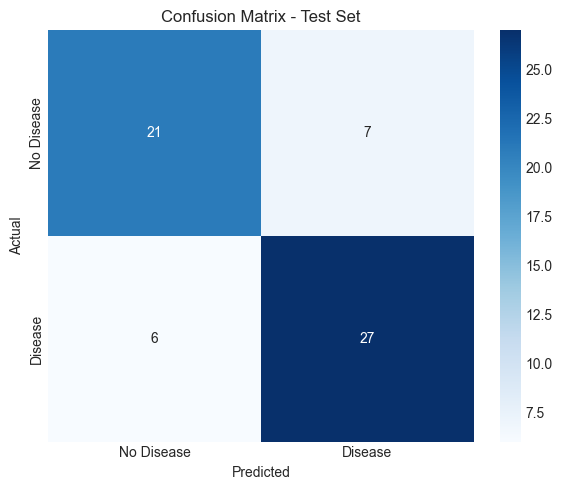

In [73]:
"""
===================================================================================
EVALUASI FINAL: MODEL TERBAIK PADA TEST SET (20%)
===================================================================================
Mengambil konfigurasi terbaik dari Nested CV dan evaluasi pada test set.
===================================================================================
"""

print("=" * 80)
print("🏆 EVALUASI MODEL TERBAIK PADA TEST SET")
print("=" * 80)

# Cari konfigurasi terbaik berdasarkan F1 Score
best_config = df_nested_cv.loc[df_nested_cv['F1_Mean'].idxmax()]

print(f"\n📊 Konfigurasi Terbaik (dari Nested CV):")
print(f"  Scenario:    {best_config['Scenario']}")
print(f"  Estimators:  {int(best_config['Estimators'])}")
print(f"  Features:    {best_config['Features']:.1f}")
print(f"  F1 Score:    {best_config['F1_Mean']:.4f} ± {best_config['F1_Std']:.4f}")

# Reconstruct feature selection logic
scenario_name = best_config['Scenario']
if 'Baseline' in scenario_name:
    fitur_mode = 'Baseline'
elif 'PCC' in scenario_name and 'Combined' not in scenario_name:
    fitur_mode = 'PCC_Scenario'
elif 'Chi2' in scenario_name and 'Combined' not in scenario_name:
    fitur_mode = 'Chi2_Scenario'
else:
    fitur_mode = 'Combined'

# Select features
if fitur_mode == 'Baseline':
    fitur_final = list(X_train_final.columns)
    
elif fitur_mode == 'PCC_Scenario':
    fitur_final = (
        pcc_selection(X_train_final, y_train_final, best_config['PCC_Threshold'])
        + FITUR_kategorikal
    )
    
elif fitur_mode == 'Chi2_Scenario':
    fitur_final = (
        FITUR_KONTINYU
        + chi2_selection(X_train_final, y_train_final, int(best_config['Chi2_K']))
    )
    
else:  # Combined
    pcc_features = pcc_selection(X_train_final, y_train_final, best_config['PCC_Threshold'])
    chi2_features = chi2_selection(X_train_final, y_train_final, int(best_config['Chi2_K']))
    fitur_final = list(set(
        pcc_features + FITUR_KONTINYU + chi2_features + FITUR_kategorikal
    ))

fitur_final = list(dict.fromkeys(fitur_final))

print(f"\n✅ Selected Features ({len(fitur_final)}): {fitur_final}")

# Train final model
X_train_selected = X_train_final[fitur_final]
X_test_selected = X_test_final[fitur_final]

model_final = ETCXGBHybrid(
    estimators=int(best_config['Estimators']),
    random_state=RANDOM_STATE
)

print(f"\n🔧 Training final model...")
model_final.fit(X_train_selected, y_train_final)

# Evaluate on test set
y_pred_test = model_final.predict(X_test_selected)

print(f"\n📈 Performance pada Test Set (20%):")
print(f"  Accuracy:    {accuracy_score(y_test_final, y_pred_test):.4f}")
print(f"  Precision:   {precision_score(y_test_final, y_pred_test, zero_division=0):.4f}")
print(f"  Recall:      {recall_score(y_test_final, y_pred_test, zero_division=0):.4f}")
print(f"  Specificity: {hitung_specificity(y_test_final, y_pred_test):.4f}")
print(f"  F1 Score:    {f1_score(y_test_final, y_pred_test, zero_division=0):.4f}")

# Confusion Matrix
cm_test = confusion_matrix(y_test_final, y_pred_test)
print(f"\n📊 Confusion Matrix (Test Set):")
print(f"  TN: {cm_test[0,0]:3d} | FP: {cm_test[0,1]:3d}")
print(f"  FN: {cm_test[1,0]:3d} | TP: {cm_test[1,1]:3d}")

# Visualization
import matplotlib.pyplot as plt
import seaborn as sns

fig, ax = plt.subplots(1, 1, figsize=(6, 5))
sns.heatmap(cm_test, annot=True, fmt='d', cmap='Blues', ax=ax,
            xticklabels=['No Disease', 'Disease'],
            yticklabels=['No Disease', 'Disease'])
ax.set_xlabel('Predicted')
ax.set_ylabel('Actual')
ax.set_title('Confusion Matrix - Test Set')
plt.tight_layout()
plt.show()

print("=" * 80)